<a href="https://colab.research.google.com/github/DaviMatoso/MachineLearning/blob/main/Modelo_aplica%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparação do ambiente

In [ ]:
#Instalar bibliotecas necessárias (descomente se necessário)
!pip install seaborn plotly missingno category_encoders

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno
import category_encoders as ce

from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

**Ferramentas necessárias para construção dos modelos**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor

In [ ]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
url = "/content/credito_aplicacao_clientes_final.csv"
df = pd.read_csv(url)

In [ ]:
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")

Dimensões: 3000 linhas × 19 colunas


In [ ]:
print("Tipos de dados")
print(df.dtypes)

Tipos de dados
id_cliente                           int64
uf                                  object
municipio                           object
segmento_cliente                    object
natureza_juridica                   object
fonte_cliente                       object
cnae_codigo                         object
capital_social                      object
idade_cnpj                          object
serasa_contagem_negativacoes       float64
serasa_contagem_protestos          float64
serasa_credores                     object
serasa_socio_tem_negativacao       float64
ifood_contagem_avaliacoes           object
ifood_faixa_preco                   object
google_maps_avaliacao               object
google_maps_contagem_avaliacoes     object
google_maps_tem_website            float64
inadimplente                       float64
dtype: object


In [ ]:
print("Vizualização da tabela")
display(df.head(5))

Vizualização da tabela


,id_cliente,uf,municipio,segmento_cliente,natureza_juridica,fonte_cliente,cnae_codigo,capital_social,idade_cnpj,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_credores,serasa_socio_tem_negativacao,ifood_contagem_avaliacoes,ifood_faixa_preco,google_maps_avaliacao,google_maps_contagem_avaliacoes,google_maps_tem_website,inadimplente
0,1000732585882,CE,CAUCAIA,Segmento 2,213-5 - Empresário (Individual),Fonte 1,77.49-8-16,"(1500, 2000]","(3000, 4000]",0.0,0.0,NaN,0.0,"(50, 100]",$$,NaN,NaN,NaN,0.0
1,1001250740869,CE,FORTALEZA,Segmento 10,206-2 - Sociedade Empresária Limitada,Fonte 5,39.87-6-92,"(8000, 10000]","(25, 50]",3.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
2,1002669165825,CE,CAUCAIA,Segmento 20,213-5 - Empresário (Individual),Fonte 1,53.35-1-24,"(1500, 2000]","(3000, 4000]",5.0,0.0,"Financeiro, Comércio, Tecnologia",1.0,NaN,NaN,NaN,NaN,NaN,0.0
3,1003899664289,CE,FORTALEZA,Segmento 16,213-5 - Empresário (Individual),Fonte 1,77.74-5-45,"(2000, 3000]","(900, 1150]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
4,1005577842775,CE,FORTALEZA,Segmento 18,213-5 - Empresário (Individual),Fonte 1,53.35-1-24,"(8000, 10000]","(600, 750]",1.0,1.0,Saúde,0.0,NaN,NaN,NaN,NaN,NaN,0.0


In [ ]:
print("\n ESTATÍSTICAS DESCRITIVAS:")
display(df.describe())


 ESTATÍSTICAS DESCRITIVAS:


,id_cliente,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_socio_tem_negativacao,google_maps_tem_website,inadimplente
count,3.000000e+03,3000.000000,3000.000000,3000.000000,208.0,3000.000000
mean,4.350547e+12,1.003000,0.263333,0.475667,1.0,0.313333
std,1.908418e+12,4.464635,1.936295,0.499491,0.0,0.463926
min,1.000733e+12,0.000000,0.000000,0.000000,1.0,0.000000
25%,2.785241e+12,0.000000,0.000000,0.000000,1.0,0.000000
50%,4.344222e+12,0.000000,0.000000,0.000000,1.0,0.000000
75%,5.961011e+12,0.000000,0.000000,1.000000,1.0,1.000000
max,7.709813e+12,141.000000,79.000000,1.000000,1.0,1.000000


In [ ]:
target_var = 'inadimplente'

# Tratamento de Nulos

Análise de nulos:


,0
id_cliente,0
uf,0
municipio,0
segmento_cliente,0
natureza_juridica,0
fonte_cliente,0
cnae_codigo,0
capital_social,0
idade_cnpj,0
serasa_contagem_negativacoes,0


<Axes: >

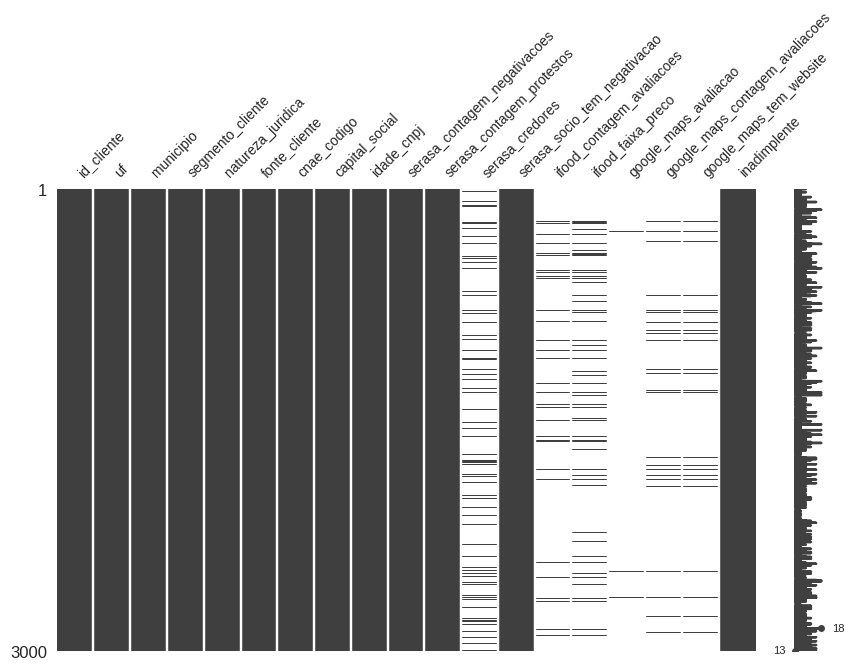

In [ ]:
#Análise de valores faltantes
print("Análise de nulos:")
display(df.isna().sum())

#visualização
msno.matrix(df, figsize=(10, 6), fontsize=10)

In [ ]:
#google maps
cols = [
    'google_maps_avaliacao',
    'google_maps_contagem_avaliacoes',
    'google_maps_tem_website'
]

mask_sem_gmaps = df[cols].isna().all(axis=1)

print(mask_sem_gmaps.sum())

2792


In [ ]:
df['tem_google_maps'] = np.where(mask_sem_gmaps, 0, 1)

In [ ]:
#ifood
cols_ifood = [
   'ifood_contagem_avaliacoes',
   'ifood_faixa_preco'
]

mask_sem_ifood = df[cols_ifood].isna().all(axis=1)

print(mask_sem_ifood.sum())

2637


In [ ]:
df['tem_ifood'] = np.where(mask_sem_ifood, 0, 1)

In [ ]:
#serasa credores ( No caso do cliente não dever para outra empresa, o campo é nulo.)
df['serasa_credores'] = df['serasa_credores'].fillna("Sem credor")

In [ ]:
df1 = df.drop(columns = ['ifood_faixa_preco','ifood_contagem_avaliacoes','google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'google_maps_tem_website'])

Análise de nulos:


,0
id_cliente,0
uf,0
municipio,0
segmento_cliente,0
natureza_juridica,0
fonte_cliente,0
cnae_codigo,0
capital_social,0
idade_cnpj,0
serasa_contagem_negativacoes,0


<Axes: >

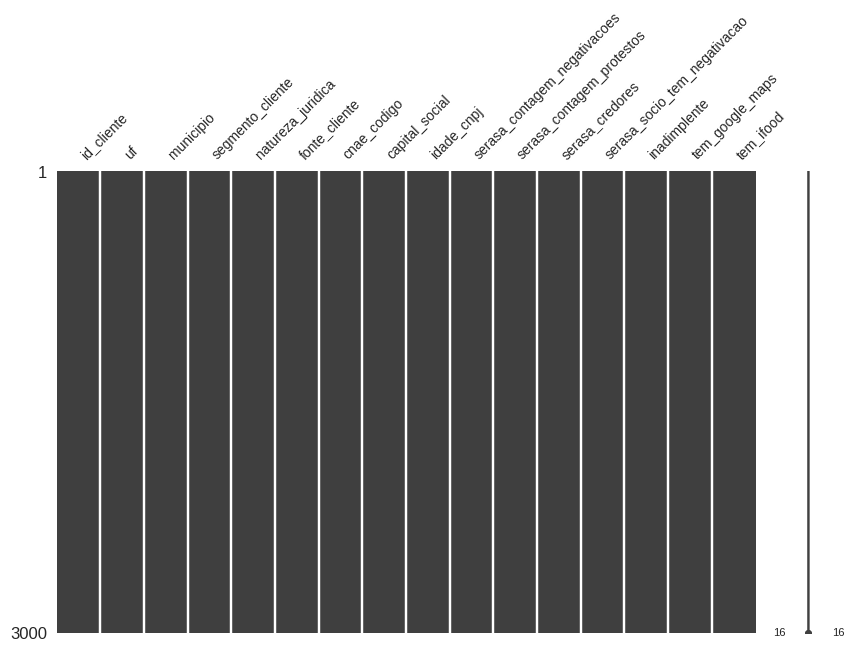

In [ ]:
#Análise de valores faltantes
print("Análise de nulos:")
display(df1.isna().sum())

#visualização
msno.matrix(df1, figsize=(10, 6), fontsize=10)

# Análise Univariada

In [ ]:
# Separar variáveis por tipo
numeric_vars = df1.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df1.select_dtypes(include=['object']).columns.tolist()


In [ ]:
#Visualização e retirada de ID da lista de variáveis numéricas para EDA
numerico = [col for col in numeric_vars if col != 'id_cliente']

print(f"Variáveis numéricas: {numerico}")
print(f"Variáveis categóricas: {categorical_vars}")

Variáveis numéricas: ['serasa_contagem_negativacoes', 'serasa_contagem_protestos', 'serasa_socio_tem_negativacao', 'inadimplente', 'tem_google_maps', 'tem_ifood']
Variáveis categóricas: ['uf', 'municipio', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente', 'cnae_codigo', 'capital_social', 'idade_cnpj', 'serasa_credores']


## Categóricas e Intervalos

In [ ]:
# Análise de frequências
for var in categorical_vars:
    if var in df1.columns:
        print(f"\n {var.upper()}:")
        freq_table = df1[var].value_counts()
        freq_percent = df1[var].value_counts(normalize=True) * 100

        freq_df1 = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df1.head(10))

        # Medida de concentração
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


 UF:
    Frequência  Percentual
uf                        
CE        3000       100.0
  Entropia: 0.000

 MUNICIPIO:
           Frequência  Percentual
municipio                        
FORTALEZA        1934   64.466667
CAUCAIA           347   11.566667
MARACANAU         109    3.633333
AQUIRAZ            85    2.833333
EUSEBIO            64    2.133333
ARACATI            63    2.100000
HORIZONTE          47    1.566667
CASCAVEL           42    1.400000
ITAITINGA          41    1.366667
BEBERIBE           39    1.300000
  Entropia: 1.555

 SEGMENTO_CLIENTE:
                  Frequência  Percentual
segmento_cliente                        
Segmento 16              613   20.433333
Segmento 20              609   20.300000
Segmento 15              343   11.433333
Segmento 18              300   10.000000
Segmento 10              211    7.033333
Segmento 19              210    7.000000
Segmento 5               162    5.400000
Segmento 9                94    3.133333
Segmento 3                

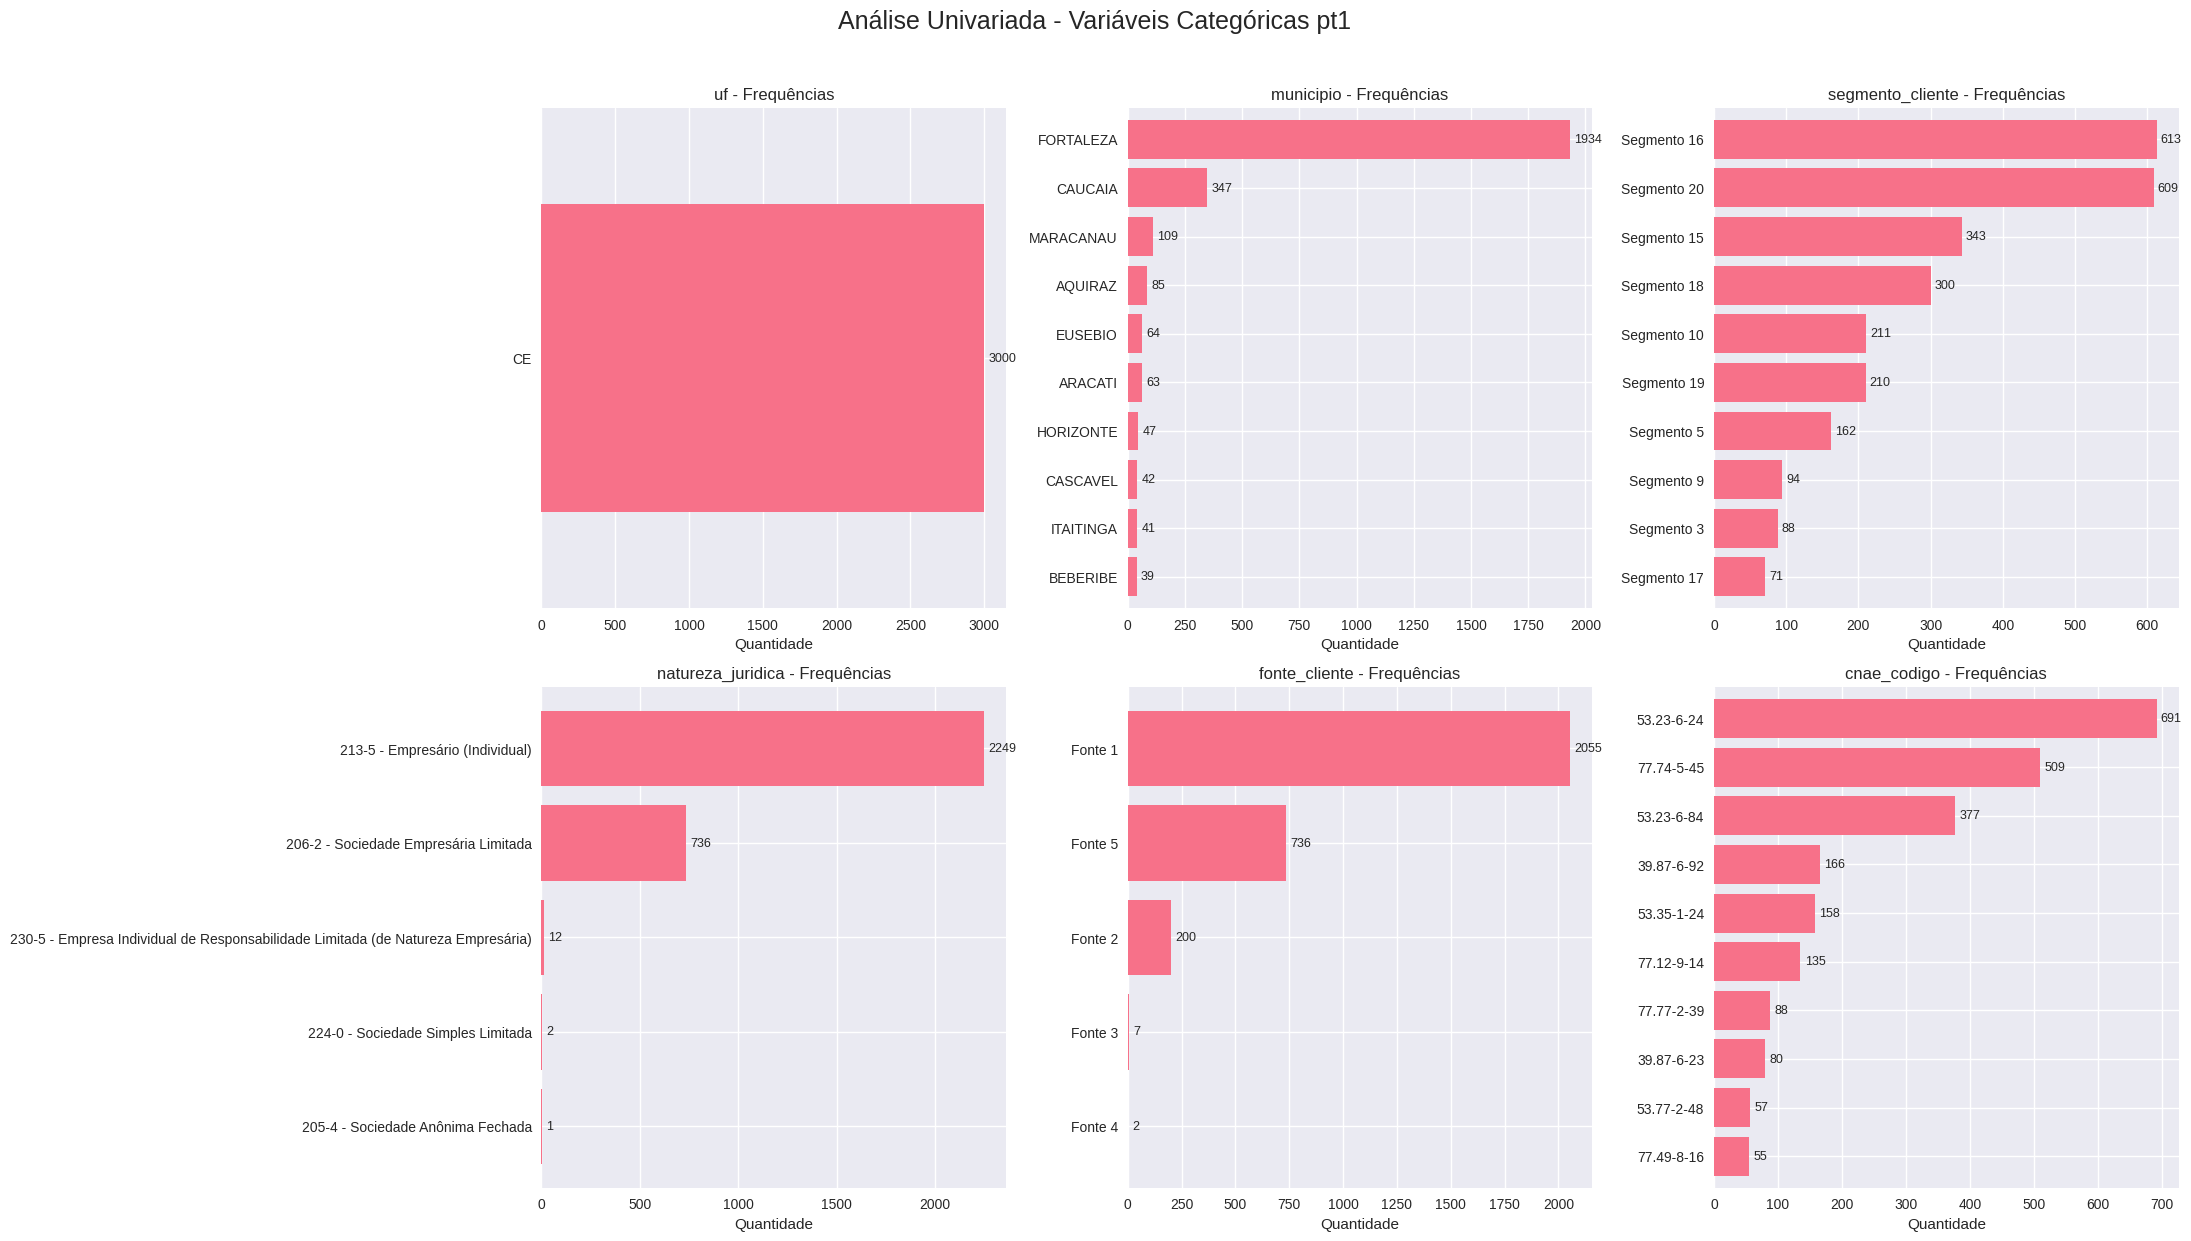

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    4,
    3,
    figsize=(22, 24)
)

fig.suptitle(
    'Análise Univariada - Variáveis Categóricas pt1',
    fontsize=18
)

axes = axes.flatten()

for i, var in enumerate(categorical_vars[:6]):

    if var in df1.columns:

        # Top 10 categorias mais frequentes
        value_counts = (
            df1[var]
            .value_counts()
            .head(10)
            .sort_values()
        )

        # Sempre gráfico horizontal
        value_counts.plot(
            kind='barh',
            ax=axes[i],
            width=0.8
        )

        axes[i].set_title(
            f'{var} - Frequências',
            fontsize=12
        )

        axes[i].set_xlabel('Quantidade')
        axes[i].set_ylabel('')

        # Coloca os valores ao lado das barras
        for container in axes[i].containers:
            axes[i].bar_label(
                container,
                padding=3,
                fontsize=9
            )

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])



plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

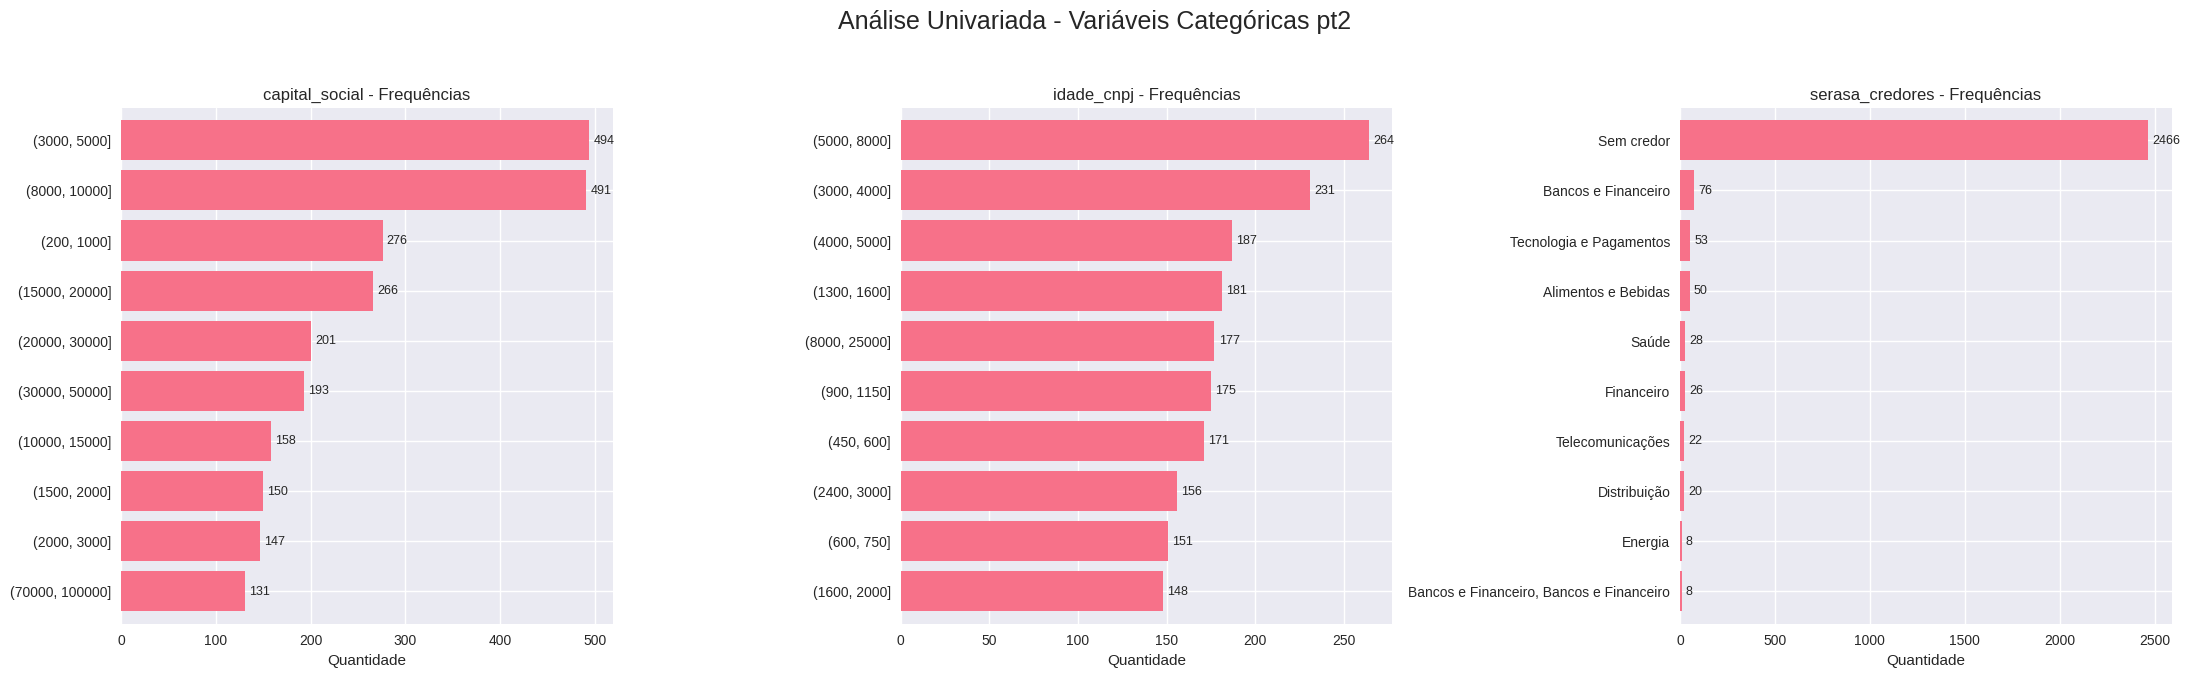

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    4,
    3,
    figsize=(22, 24)
)

fig.suptitle(
    'Análise Univariada - Variáveis Categóricas pt2',
    fontsize=18
)

axes = axes.flatten()

for i, var in enumerate(categorical_vars[6:]):

    if var in df1.columns:

        # Top 10 categorias mais frequentes
        value_counts = (
            df1[var]
            .value_counts()
            .head(10)
            .sort_values()
        )

        # Sempre gráfico horizontal
        value_counts.plot(
            kind='barh',
            ax=axes[i],
            width=0.8
        )

        axes[i].set_title(
            f'{var} - Frequências',
            fontsize=12
        )

        axes[i].set_xlabel('Quantidade')
        axes[i].set_ylabel('')

        # Coloca os valores ao lado das barras
        for container in axes[i].containers:
            axes[i].bar_label(
                container,
                padding=3,
                fontsize=9
            )

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])



plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

## Numéricas

In [ ]:
todos_numericos_analise = ["serasa_contagem_negativacoes", "serasa_contagem_protestos","serasa_socio_tem_negativacao", "inadimplente", "tem_google_maps", "tem_ifood" ]
numericas_para_analise = ["serasa_contagem_negativacoes", "serasa_contagem_protestos"] #Foram retiradas as variáveis binárias para determinadas análises
binarias_para_analise = ["serasa_socio_tem_negativacao", "inadimplente"]

In [ ]:
# Análise de frequências
for var in todos_numericos_analise:
    if var in df1.columns:
        print(f"\n {var.upper()}:")
        freq_table = df1[var].value_counts()
        freq_percent = df1[var].value_counts(normalize=True) * 100

        freq_df1 = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df1.head(10))

        # Medida de concentração
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


 SERASA_CONTAGEM_NEGATIVACOES:
                              Frequência  Percentual
serasa_contagem_negativacoes                        
0.0                                 2369   78.966667
1.0                                  212    7.066667
2.0                                  126    4.200000
3.0                                   73    2.433333
4.0                                   49    1.633333
6.0                                   35    1.166667
5.0                                   27    0.900000
7.0                                   17    0.566667
8.0                                   16    0.533333
10.0                                  12    0.400000
  Entropia: 0.983

 SERASA_CONTAGEM_PROTESTOS:
                           Frequência  Percentual
serasa_contagem_protestos                        
0.0                              2769   92.300000
1.0                               104    3.466667
2.0                                46    1.533333
3.0                                

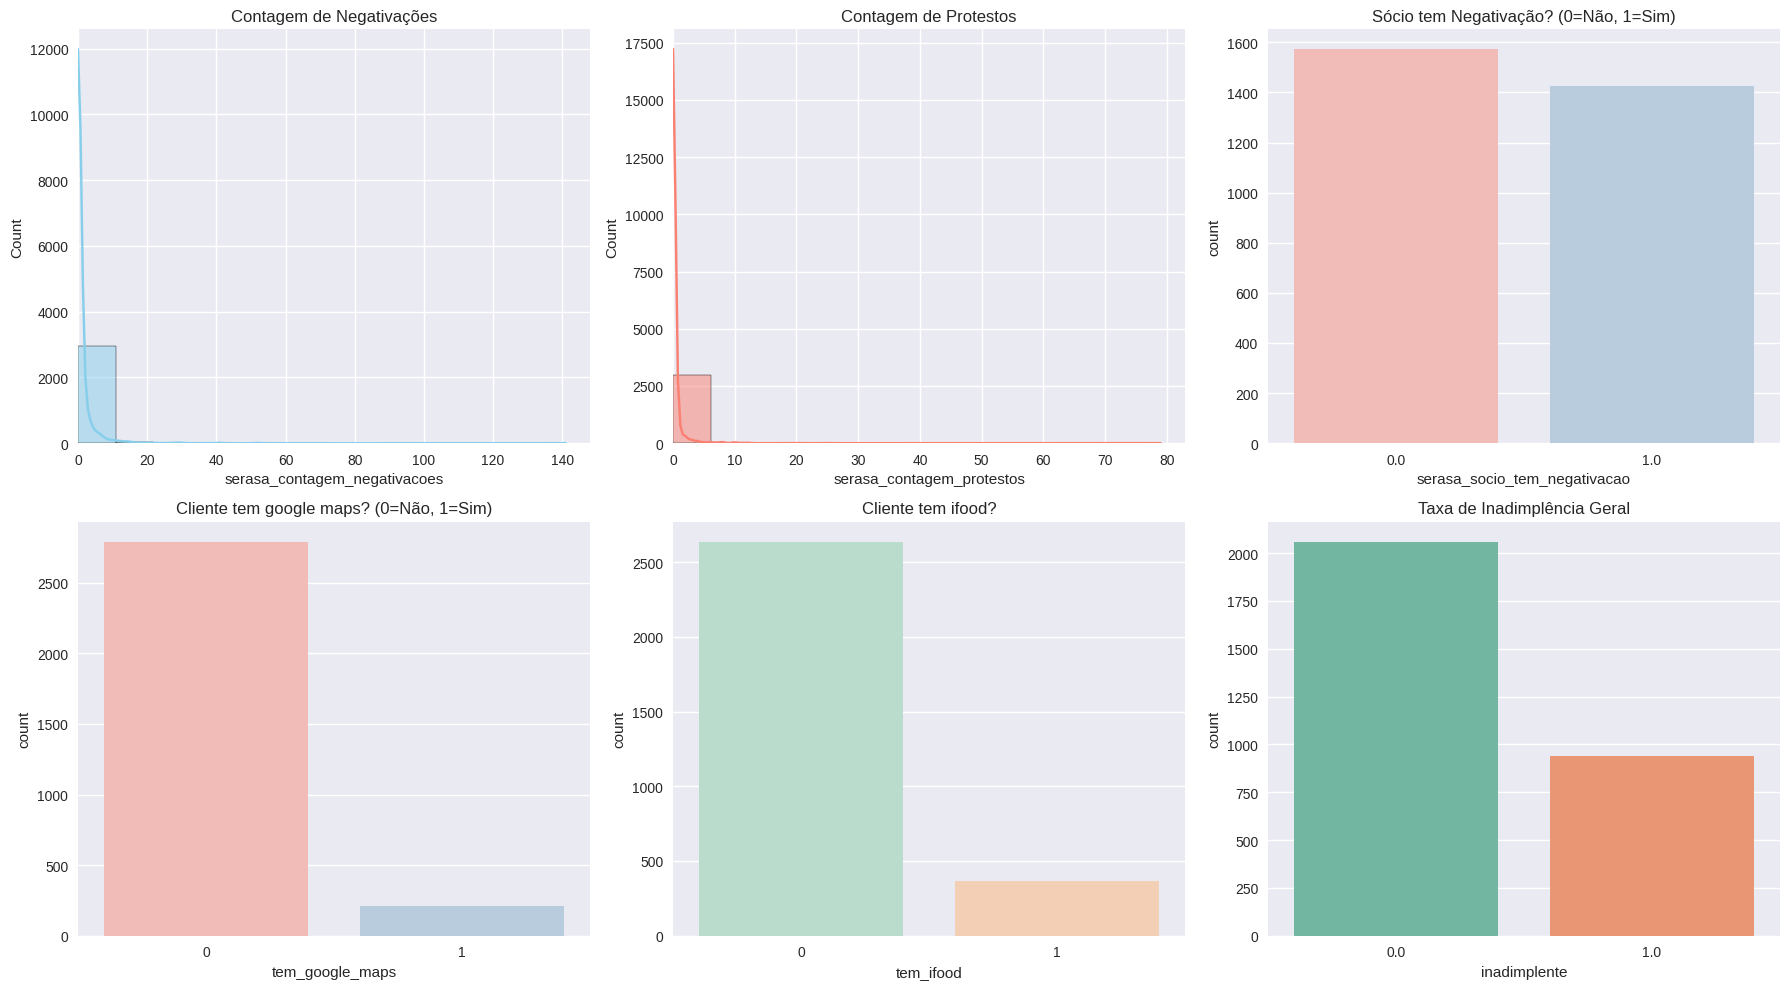

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Variáveis numéricas contínuas
sns.histplot(data=df1, x='serasa_contagem_negativacoes', ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Contagem de Negativações')
axes[0].set_xlim(left=0) #gráfico começa no zero

sns.histplot(data=df1, x='serasa_contagem_protestos', ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Contagem de Protestos')
axes[1].set_xlim(left=0) #gráfico começa no zero

# Variáveis binárias
sns.countplot(data=df1, x='serasa_socio_tem_negativacao', ax=axes[2], palette='Pastel1', hue='serasa_socio_tem_negativacao', legend=False)
axes[2].set_title('Sócio tem Negativação? (0=Não, 1=Sim)')

sns.countplot(data=df1, x='tem_google_maps', ax=axes[3], palette='Pastel1', hue='tem_google_maps', legend=False)
axes[3].set_title('Cliente tem google maps? (0=Não, 1=Sim)')

sns.countplot(data=df1, x='tem_ifood', ax=axes[4], palette='Pastel2', hue='tem_ifood', legend=False)
axes[4].set_title('Cliente tem ifood?')

# Target
sns.countplot(data=df1, x='inadimplente', ax=axes[5], palette='Set2', hue='inadimplente', legend=False)
axes[5].set_title('Taxa de Inadimplência Geral')

plt.tight_layout()
plt.show()

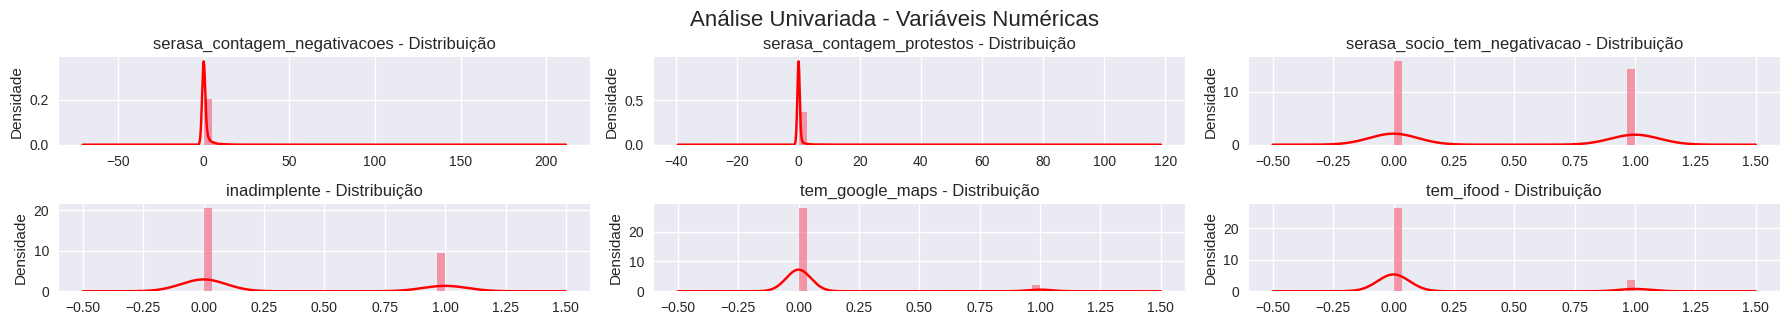

In [ ]:
# Visualizações das variáveis numéricas
num_vars_to_plot = len(numerico)
num_cols = 3
num_rows = (num_vars_to_plot + num_cols - 1) #num_colss

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 12))
fig.suptitle('Análise Univariada - Variáveis Numéricas', fontsize=16)

axes = axes.flatten()

for i, var in enumerate(numerico):
    if var in df1.columns:
        data = df[var].dropna()

        # Histograma + Densidade
        axes[i].hist(data, bins=30, alpha=0.7, density=True)

        if data.std() != 0:
            data.plot.density(ax=axes[i], color='red')
        else:
            axes[i].axvline(x=data.iloc[0], color='red', linestyle='--')

        axes[i].set_title(f'{var} - Distribuição')
        axes[i].set_ylabel('Densidade')

for j in range(num_vars_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
#Outliers
for var in numericas_para_analise:
    if var in df1.columns:
        print(f"\n{var.upper()}:")
        data = df1[var].dropna()

        # Estatísticas básicas
        print(f"  Mean: {data.mean():.2f}")
        print(f"  Std: {data.std():.2f}")
        print(f"  Skewness: {stats.skew(data):.2f}")
        print(f"  Kurtosis: {stats.kurtosis(data):.2f}")

        # Outliers (IQR method)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


SERASA_CONTAGEM_NEGATIVACOES:
  Mean: 1.00
  Std: 4.46
  Skewness: 14.98
  Kurtosis: 365.76
  Outliers: 631 (21.0%)

SERASA_CONTAGEM_PROTESTOS:
  Mean: 0.26
  Std: 1.94
  Skewness: 25.41
  Kurtosis: 936.62
  Outliers: 231 (7.7%)


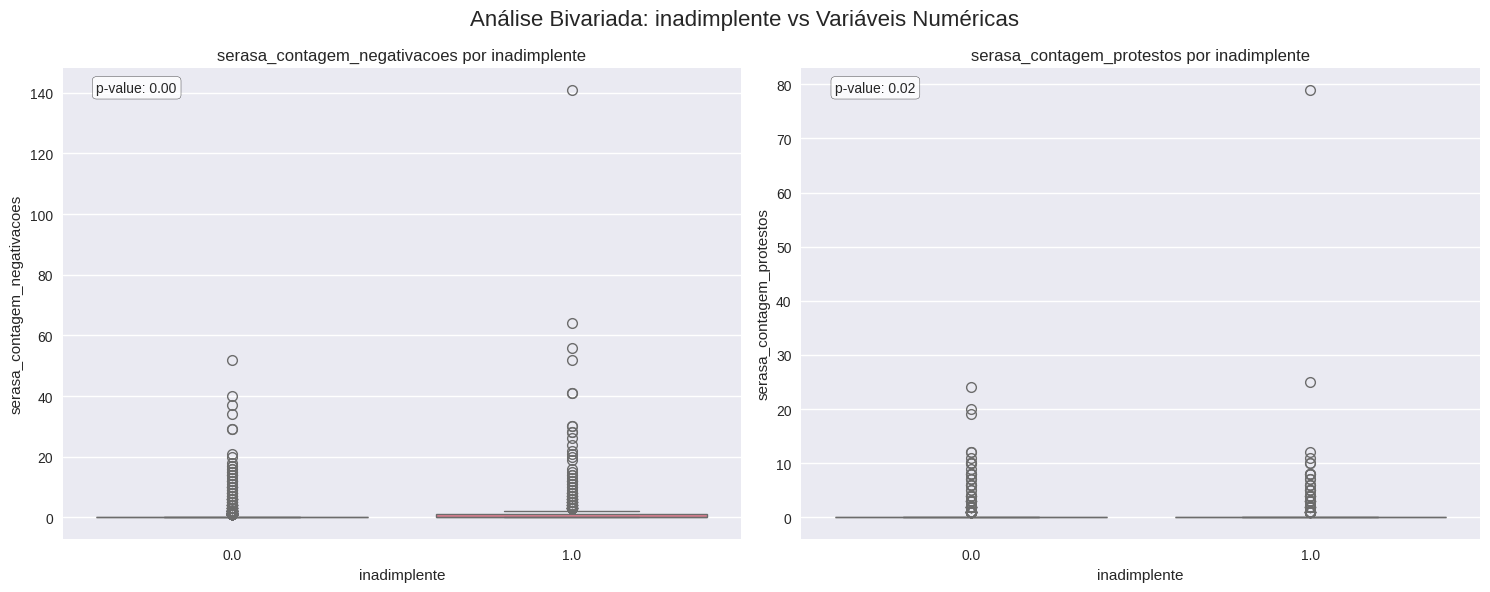

In [ ]:
# visualização outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Análise Bivariada: {target_var} vs Variáveis Numéricas', fontsize=16)
numeric_for_analysis = ['serasa_contagem_negativacoes', 'serasa_contagem_protestos']
for i, var in enumerate(numeric_for_analysis):
    if var in df.columns:
        col = i % 2

        # Box plot por categoria do target
        sns.boxplot(data=df1, x=target_var, y=var, ax=axes[col])
        axes[col].set_title(f'{var} por {target_var}')

        # Teste estatístico (t-test)
        group_0 = df[df[target_var] == 0][var].dropna()
        group_1 = df[df[target_var] == 1][var].dropna()

        if len(group_0) > 0 and len(group_1) > 0:
            t_stat, p_value = stats.ttest_ind(group_0, group_1)
            axes[col].text(0.05, 0.95, f'p-value: {p_value:.2f}',
                               transform=axes[col].transAxes,
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

# Análise Bivariada

## Categóricas

Análise Bivariada: inadimplente vs Variáveis Categóricas

TABELA DE CONTINGÊNCIA - municipio:
inadimplente              0.0  1.0
municipio                         
ACARAPE                     3    2
ACARAU                      0    1
AQUIRAZ                    61   24
ARACATI                    47   16
ARACOIABA                   1    1
BARREIRA                    2    2
BATURITE                    6    0
BEBERIBE                   25   14
CASCAVEL                   29   13
CAUCAIA                   253   94
CHOROZINHO                  5    0
EUSEBIO                    46   18
FORTALEZA                1291  643
FORTIM                      9    2
GUAIUBA                     9    2
GUARAMIRANGA                8    2
HORIZONTE                  37   10
ICAPUI                      1    0
ITAICABA                    4    0
ITAITINGA                  31   10
JAGUARUANA                  0    1
JUAZEIRO DO NORTE           0    1
LIMOEIRO DO NORTE           0    1
MARACANAU                  85  

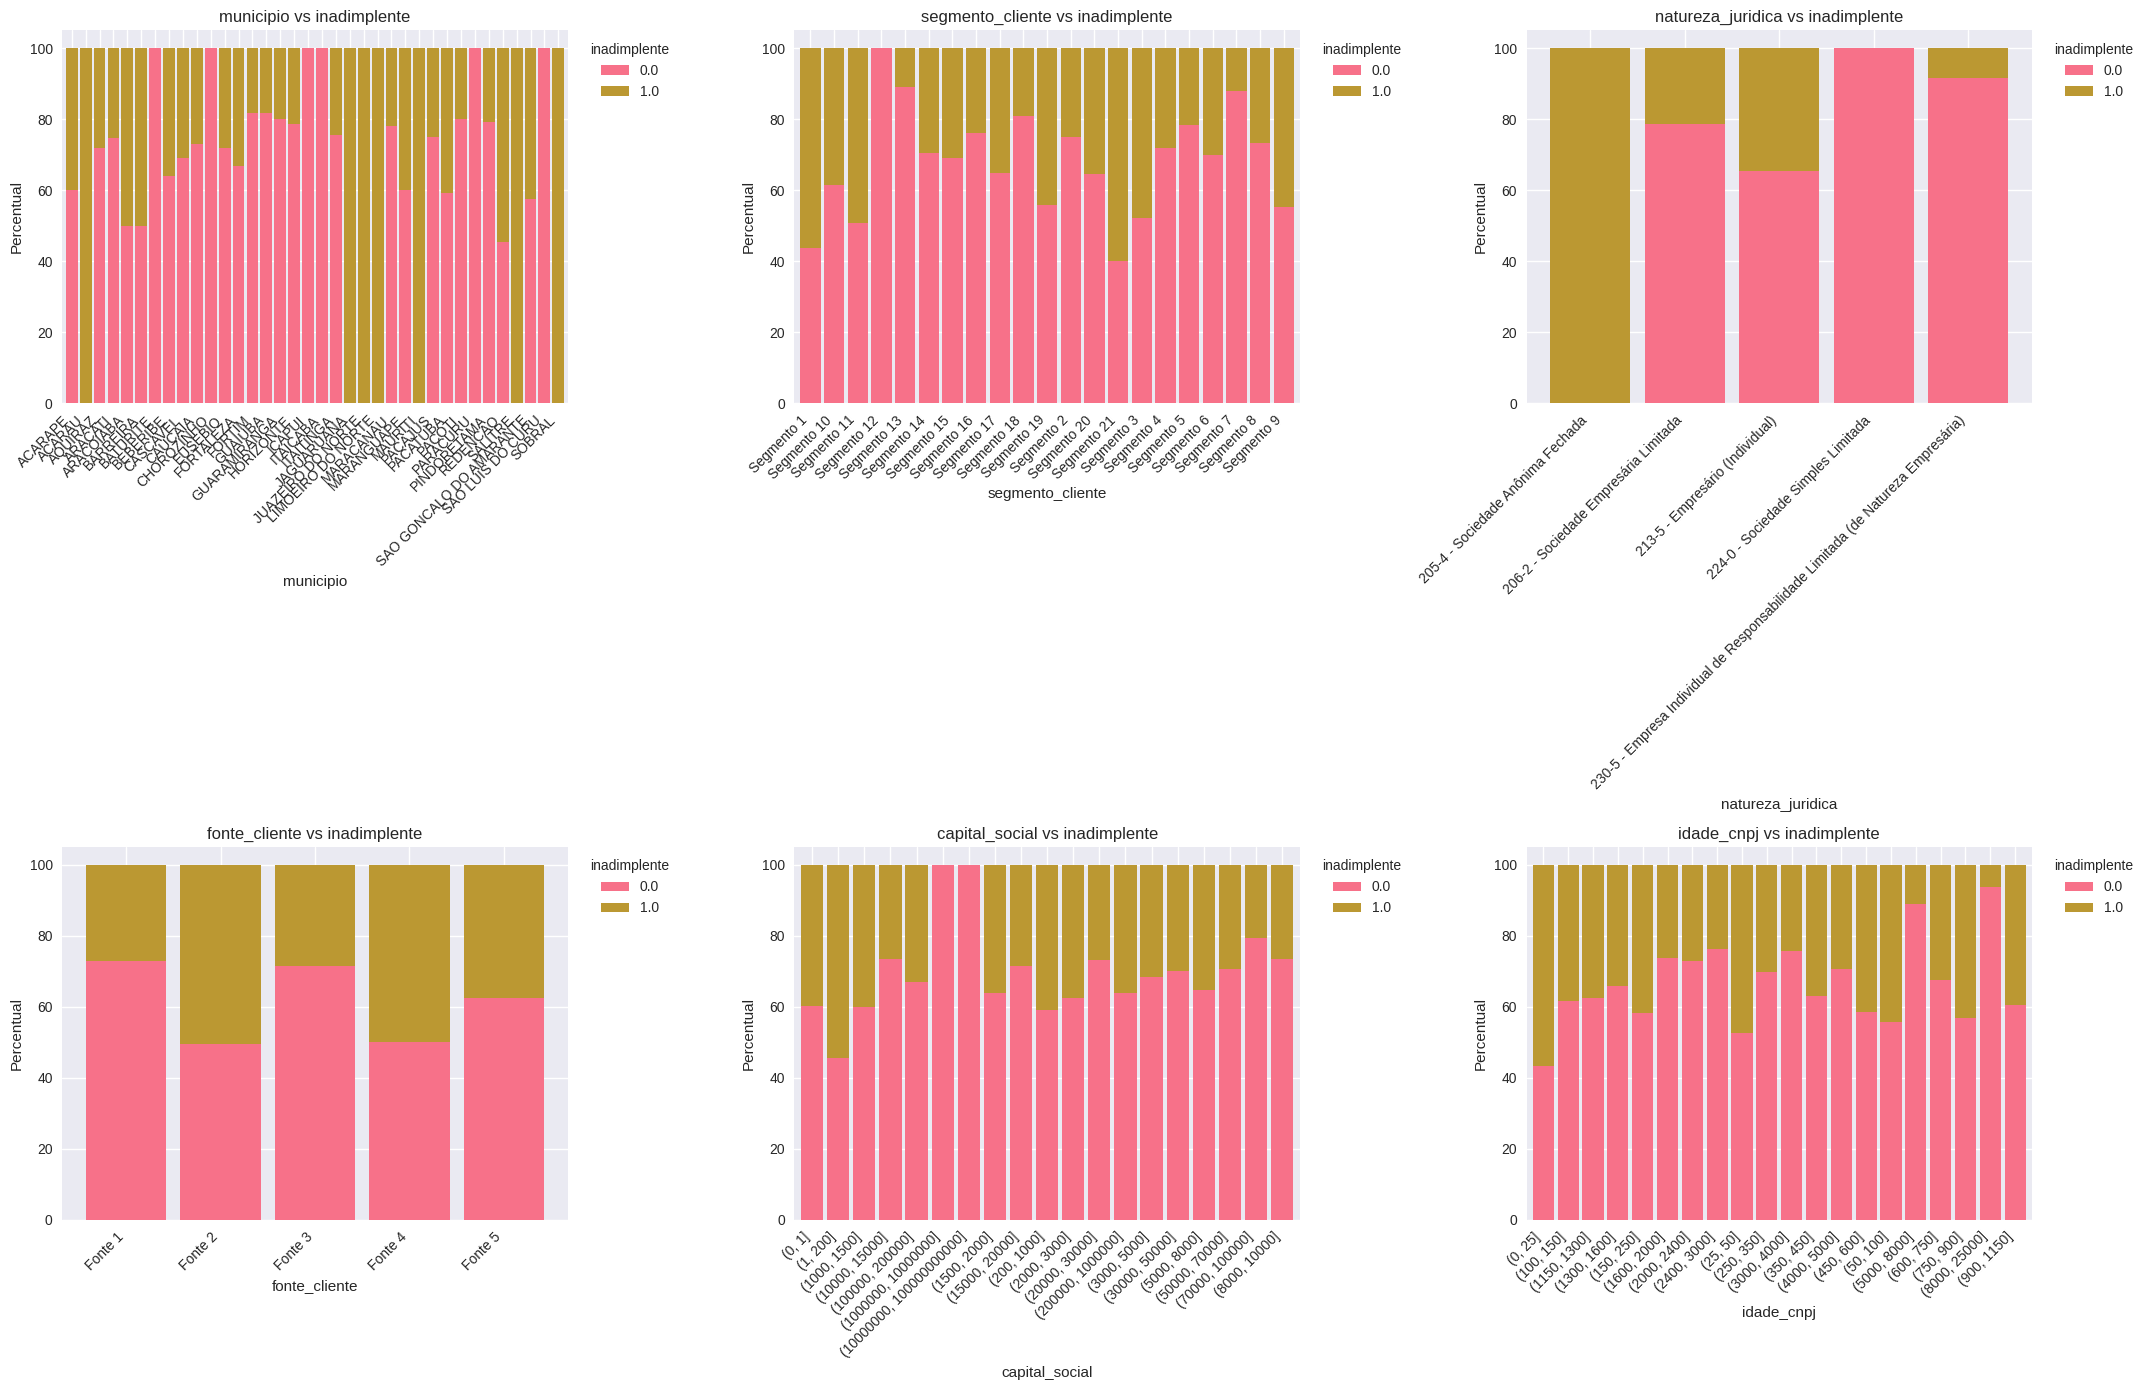

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Algumas categorias foram removidas por gerarem gráficos ilegíveis
categoricas_para_analise = [
  'municipio', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente', 'capital_social', 'idade_cnpj'
]

num_vars_to_plot = len(categoricas_para_analise)

num_cols = 3
num_linhas = (num_vars_to_plot + num_cols - 1) // num_cols

fig, axes = plt.subplots(
    num_linhas,
    num_cols,
    figsize=(24, 7 * num_linhas)
)

axes = axes.flatten()

target_var = 'inadimplente'

print(f'Análise Bivariada: {target_var} vs Variáveis Categóricas')

plot_count = 0

for i, var in enumerate(categoricas_para_analise):


      # Tabela de contingência
      contingency_tabela = pd.crosstab(
          df1[var],
          df1[target_var]
      )

      print(f"\nTABELA DE CONTINGÊNCIA - {var}:")
      print(contingency_tabela)

      # Percentuais
      contingency_porcentagem = (
          pd.crosstab(
              df1[var],
              df1[target_var],
              normalize='index'
          ) * 100
      )

      print(f"\nPERCENTUAIS - {var}:")
      print(contingency_porcentagem.round(2))
      print("\n========================================")

      # Gráfico
      contingency_porcentagem.plot(
          kind='bar',
          stacked=True,
          ax=axes[plot_count],
          width=0.85
      )

      axes[plot_count].set_title(
          f'{var} vs {target_var}',
          fontsize=12
      )

      axes[plot_count].set_ylabel('Percentual')
      axes[plot_count].set_xlabel(var)

      # Legenda fora do gráfico
      axes[plot_count].legend(
          title=target_var,
          loc='upper left',
          bbox_to_anchor=(1.02, 1)
      )

      # Rótulos do eixo X
      axes[plot_count].set_xticklabels(
          contingency_porcentagem.index.astype(str),
          rotation=45,
          ha='right'
      )
      plot_count += 1

# Remove empty axes that were not used for plotting
for j in range(plot_count, len(axes)):
    fig.delaxes(axes[j])

# Ajusta espaço para legendas externas
plt.tight_layout(rect=[0, 0, 0.90, 1])

plt.show()

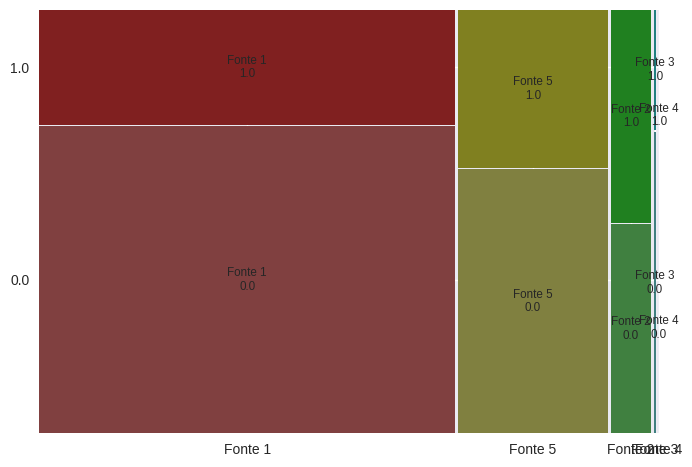

In [ ]:

mosaic(df1, ['fonte_cliente','inadimplente'])
plt.show()

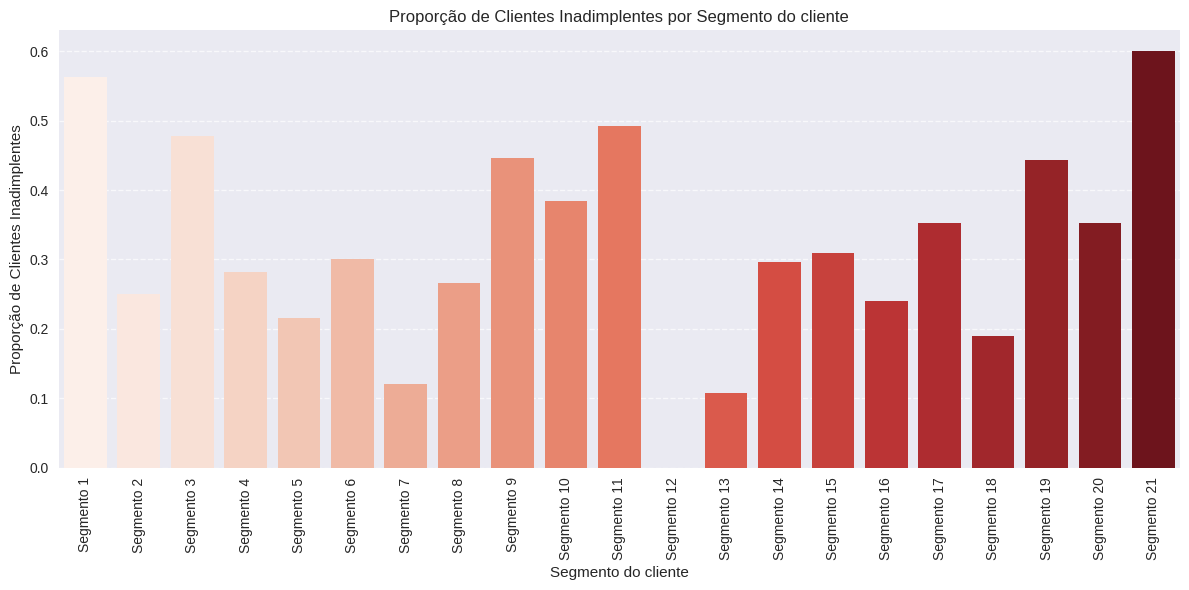

In [ ]:
idp_por_valor = df1.groupby('segmento_cliente')['inadimplente'].mean()

def extract_segment_number(segmento_str):
    # This function extracts the numerical part from strings like 'Segmento 1'
    # and handles potential non-matching strings gracefully.
    try:
        return int(segmento_str.split(' ')[1])
    except (ValueError, IndexError):
        # If it's not in the expected 'Segmento X' format,
        # assign a value that will place it appropriately (e.g., at the end).
        return float('inf') # This will sort non-matching strings to the end

idp_por_valor_sorted = idp_por_valor.copy()
idp_por_valor_sorted.index = idp_por_valor_sorted.index.map(str)

idp_por_valor_sorted = idp_por_valor_sorted.reindex(index=sorted(idp_por_valor_sorted.index, key=extract_segment_number))

# plot
plt.figure(figsize=(12, 6))
sns.barplot(x=idp_por_valor_sorted.index, y=idp_por_valor_sorted.values, palette='Reds')
plt.title('Proporção de Clientes Inadimplentes por Segmento do cliente')
plt.xlabel('Segmento do cliente')
plt.ylabel('Proporção de Clientes Inadimplentes')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Numéricas

Análise Bivariada: inadimplente vs Variáveis Categóricas

TABELA DE CONTINGÊNCIA - serasa_socio_tem_negativacao:
inadimplente                   0.0  1.0
serasa_socio_tem_negativacao           
0.0                           1225  348
1.0                            835  592

PERCENTUAIS - serasa_socio_tem_negativacao:
inadimplente                    0.0    1.0
serasa_socio_tem_negativacao              
0.0                           77.88  22.12
1.0                           58.51  41.49


TABELA DE CONTINGÊNCIA - tem_google_maps:
inadimplente      0.0  1.0
tem_google_maps           
0                1906  886
1                 154   54

PERCENTUAIS - tem_google_maps:
inadimplente       0.0    1.0
tem_google_maps              
0                68.27  31.73
1                74.04  25.96


TABELA DE CONTINGÊNCIA - tem_ifood:
inadimplente   0.0  1.0
tem_ifood              
0             1794  843
1              266   97

PERCENTUAIS - tem_ifood:
inadimplente    0.0    1.0
tem_ifood          

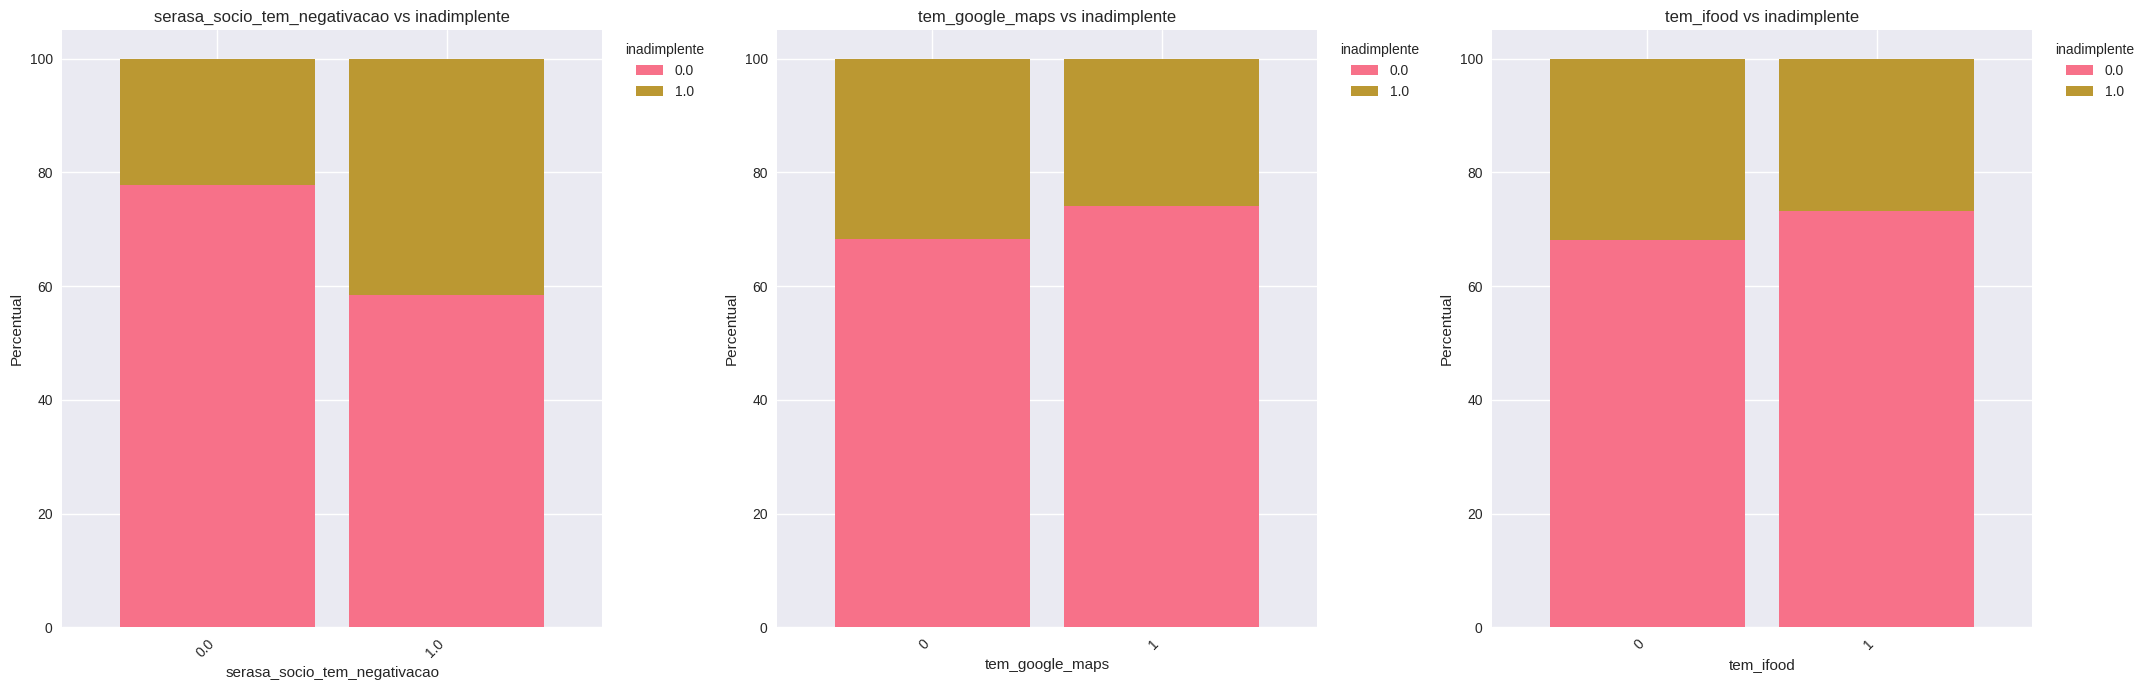

In [ ]:
binarias_para_analises = ["serasa_socio_tem_negativacao", "tem_google_maps", "tem_ifood"]
num_vars_to_plot = len(binarias_para_analises)

num_cols = 3
num_linhas = (num_vars_to_plot + num_cols - 1) // num_cols

fig, axes = plt.subplots(
    num_linhas,
    num_cols,
    figsize=(24, 7 * num_linhas)
)

axes = axes.flatten()

target_var = 'inadimplente'

print(f'Análise Bivariada: {target_var} vs Variáveis Categóricas')

plot_count = 0

for i, var in enumerate(binarias_para_analises):


      # Tabela de contingência
      contingency_tabela = pd.crosstab(
          df1[var],
          df1[target_var]
      )

      print(f"\nTABELA DE CONTINGÊNCIA - {var}:")
      print(contingency_tabela)

      # Percentuais
      contingency_porcentagem = (
          pd.crosstab(
              df1[var],
              df1[target_var],
              normalize='index'
          ) * 100
      )

      print(f"\nPERCENTUAIS - {var}:")
      print(contingency_porcentagem.round(2))
      print("\n========================================")

      # Gráfico
      contingency_porcentagem.plot(
          kind='bar',
          stacked=True,
          ax=axes[plot_count],
          width=0.85
      )

      axes[plot_count].set_title(
          f'{var} vs {target_var}',
          fontsize=12
      )

      axes[plot_count].set_ylabel('Percentual')
      axes[plot_count].set_xlabel(var)

      # Legenda fora do gráfico
      axes[plot_count].legend(
          title=target_var,
          loc='upper left',
          bbox_to_anchor=(1.02, 1)
      )

      # Rótulos do eixo X
      axes[plot_count].set_xticklabels(
          contingency_porcentagem.index.astype(str),
          rotation=45,
          ha='right'
      )
      plot_count += 1

# Remove empty axes that were not used for plotting
for j in range(plot_count, len(axes)):
    fig.delaxes(axes[j])

# Ajusta espaço para legendas externas
plt.tight_layout(rect=[0, 0, 0.90, 1])

plt.show()

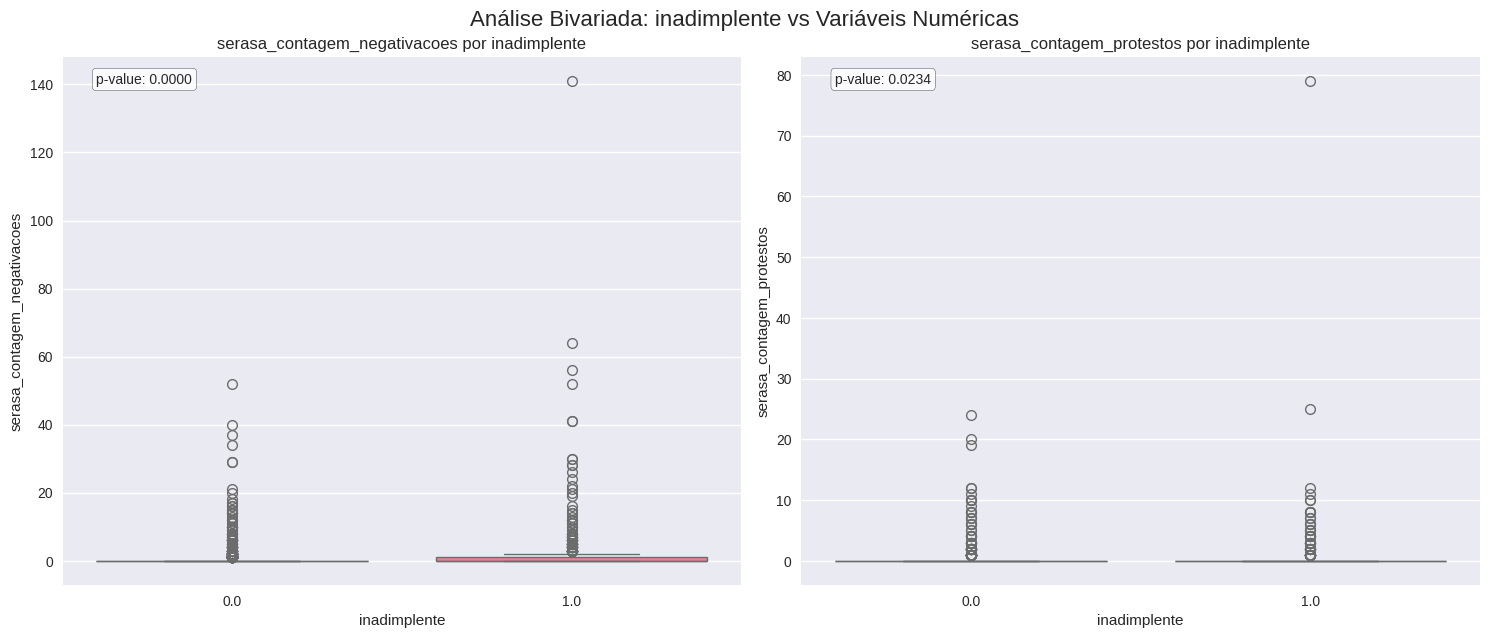

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Análise Bivariada: {target_var} vs Variáveis Numéricas', fontsize=16)

axes = axes.flatten()
plot_count = 0

for i, var in enumerate(numericas_para_analise):
    if var in df1.columns:

        # Box plot por categoria do target
        sns.boxplot(data=df1, x=target_var, y=var, ax=axes[plot_count])
        axes[plot_count].set_title(f'{var} por {target_var}')

        # Teste estatístico (t-test)
        group_0 = df1[df1[target_var] == 0][var].dropna()
        group_1 = df1[df1[target_var] == 1][var].dropna()

        if len(group_0) > 0 and len(group_1) > 0:
            t_stat, p_value = stats.ttest_ind(group_0, group_1)
            axes[plot_count].text(0.05, 0.95, f'p-value: {p_value:.4f}',
                               transform=axes[plot_count].transAxes,
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        plot_count += 1

for j in range(plot_count, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Calcular matriz de correlação
correlation_matrix = df1[todos_numericos_analise].corr()

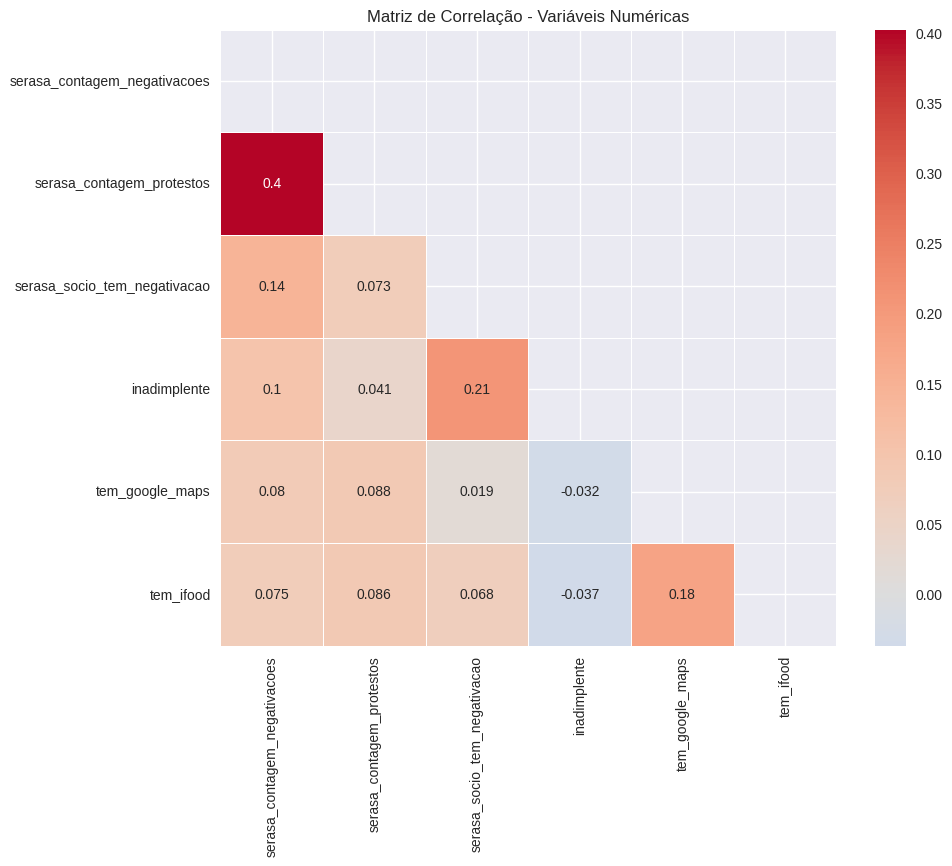

In [ ]:
# Visualizar heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

# Análise Multivariada

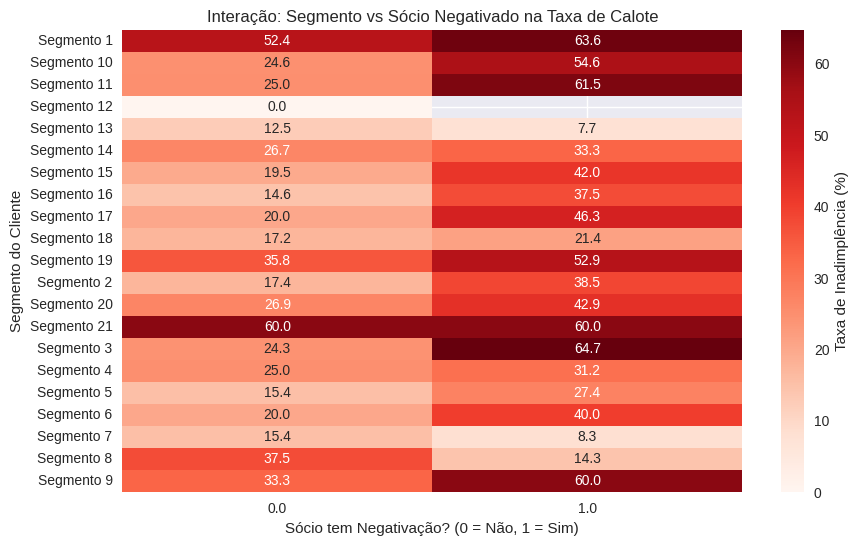

In [ ]:
#mapa de calor
mapa_risco = df1.pivot_table(
    index= 'segmento_cliente',
    columns= 'serasa_socio_tem_negativacao',
    values= 'inadimplente',
    aggfunc= 'mean'
) * 100 #Para sair em porcentagem

plt.figure(figsize=(10,6))
sns.heatmap(mapa_risco, annot= True, fmt=".1f", cmap='Reds', cbar_kws={'label': 'Taxa de Inadimplência (%)'})
plt.title('Interação: Segmento vs Sócio Negativado na Taxa de Calote')
plt.xlabel('Sócio tem Negativação? (0 = Não, 1 = Sim)')
plt.ylabel('Segmento do Cliente')
plt.show()

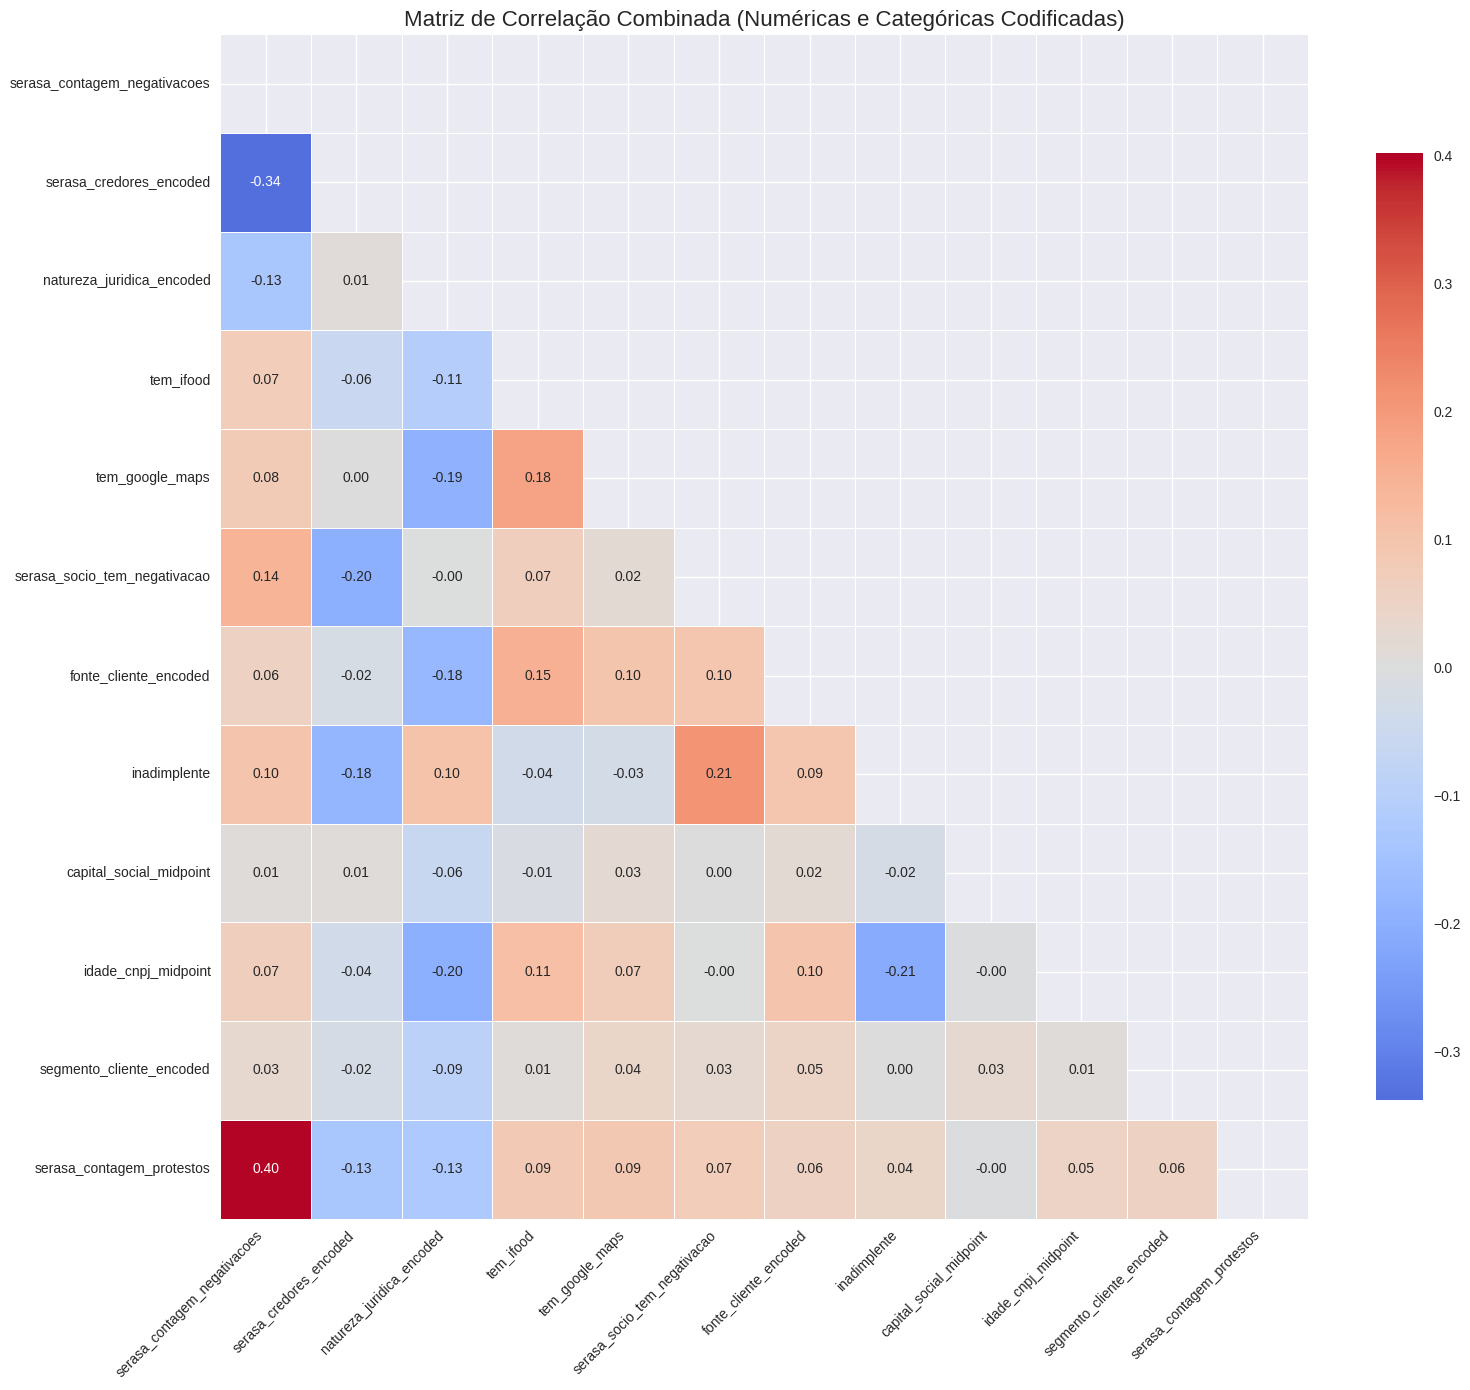

In [ ]:


df_corr_analysis = df1.copy()

def convert_interval_to_midpoint(interval_str):
    if pd.isna(interval_str) or not isinstance(interval_str, str):
        return np.nan
    try:
        parts = interval_str.replace('[', '').replace('(', '').replace(']', '').replace(')', '').split(',')
        if len(parts) == 2:
            lower = float(parts[0].strip())
            upper = float(parts[1].strip())
            return (lower + upper) / 2
        else:
            return np.nan
    except (ValueError, IndexError):
        return np.nan

df_corr_analysis['capital_social_midpoint'] = df_corr_analysis['capital_social'].apply(convert_interval_to_midpoint)
df_corr_analysis['idade_cnpj_midpoint'] = df_corr_analysis['idade_cnpj'].apply(convert_interval_to_midpoint)


numerical_features = todos_numericos_analise.copy()
numerical_features.extend(['capital_social_midpoint', 'idade_cnpj_midpoint'])
nominal_categorical_features = ['segmento_cliente', 'natureza_juridica', 'fonte_cliente', 'serasa_credores']

encoded_features = []
for col in nominal_categorical_features:
    le = LabelEncoder()
    df_corr_analysis[col + '_encoded'] = le.fit_transform(df_corr_analysis[col].fillna('Missing').astype(str))
    encoded_features.append(col + '_encoded')

all_features_for_corr_matrix = list(set(numerical_features + encoded_features))

combined_correlation_matrix = df_corr_analysis[all_features_for_corr_matrix].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(combined_correlation_matrix, dtype=bool))
sns.heatmap(combined_correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação Combinada (Numéricas e Categóricas Codificadas)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

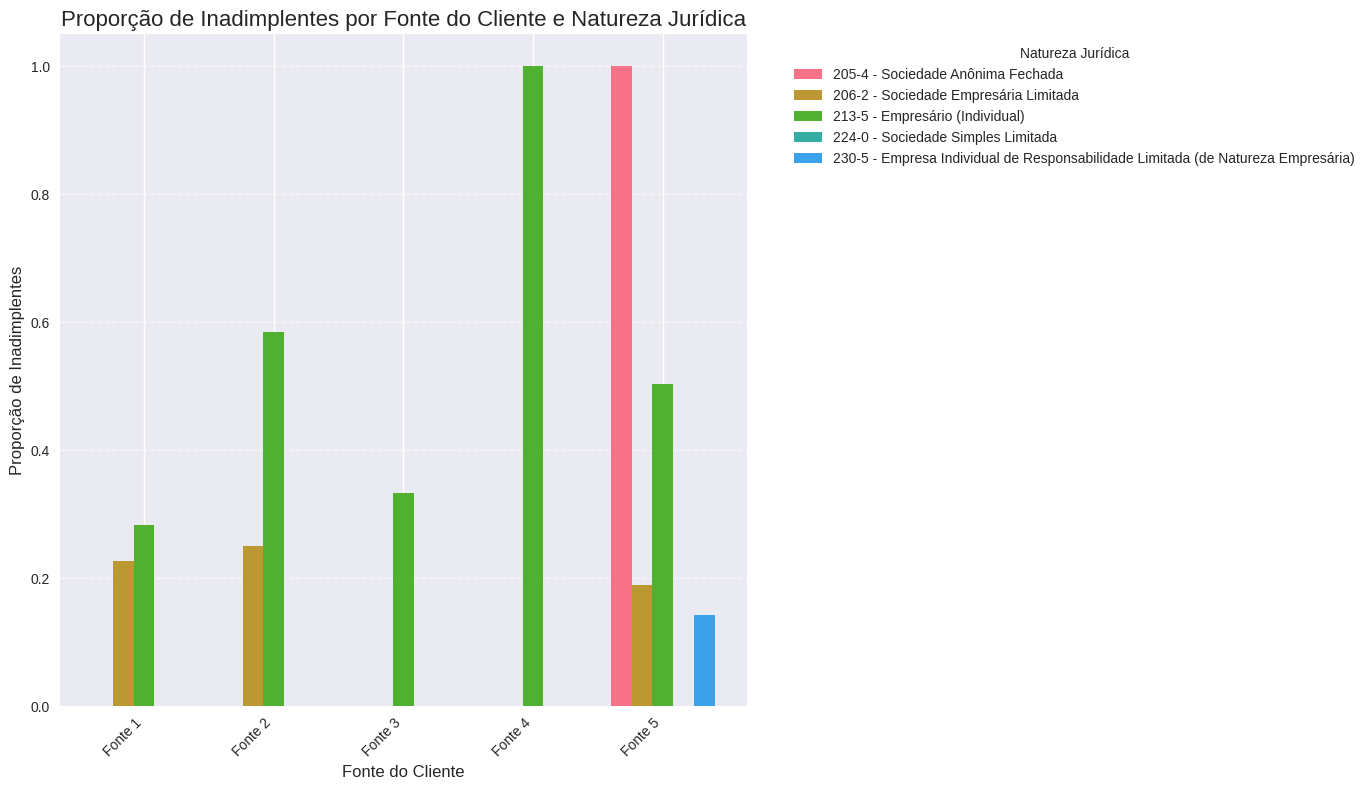

In [ ]:

multi_var_analysis = df1.groupby(['fonte_cliente', 'natureza_juridica'])[target_var].mean().unstack()

plt.figure(figsize=(14, 8))
multi_var_analysis.plot(kind='bar', figsize=(14, 8), width=0.8)

plt.title('Proporção de Inadimplentes por Fonte do Cliente e Natureza Jurídica', fontsize=16)
plt.xlabel('Fonte do Cliente', fontsize=12)
plt.ylabel('Proporção de Inadimplentes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.legend(title='Natureza Jurídica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

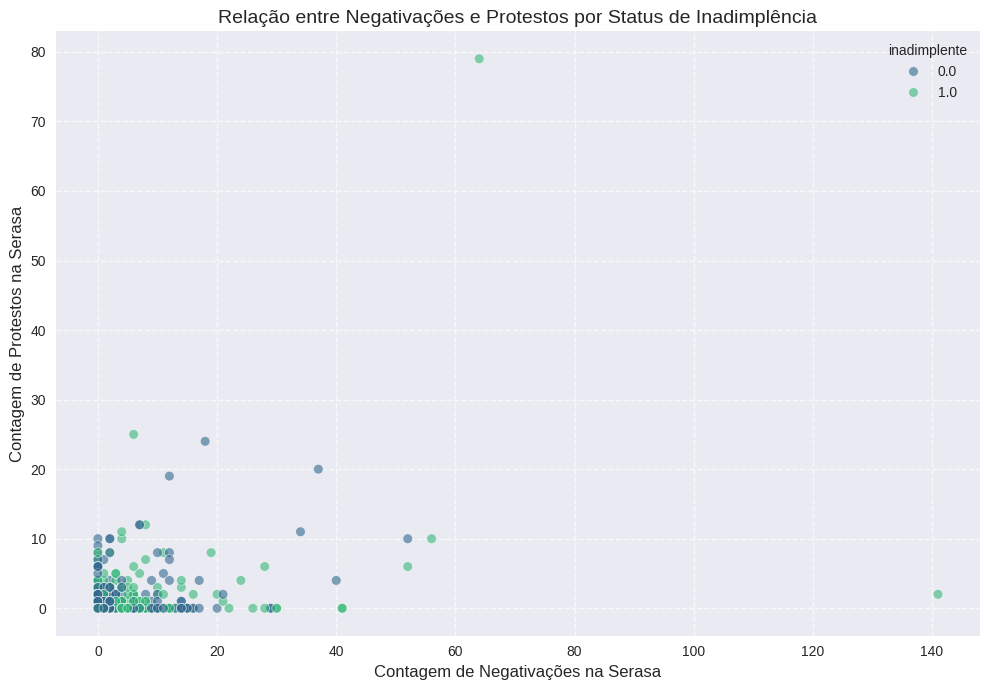

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df1,
    x='serasa_contagem_negativacoes',
    y='serasa_contagem_protestos',
    hue=target_var,
    palette='viridis',
    alpha=0.6
)
plt.title('Relação entre Negativações e Protestos por Status de Inadimplência', fontsize=14)
plt.xlabel('Contagem de Negativações na Serasa', fontsize=12)
plt.ylabel('Contagem de Protestos na Serasa', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Pré-Processamento

## Código CNAE - Tratamento


In [ ]:
df1['cnae_limpo'] = df1['cnae_codigo'].str.replace(r'[.\-]', '', regex=True)

#Cria as colunas categóricas baseadas na hierarquia
df1['cnae_divisao'] = df1['cnae_limpo'].str[:2]   # Pega os 2 primeiros caracteres
df1['cnae_grupo'] = df1['cnae_limpo'].str[:3]     # Pega os 3 primeiros caracteres
df1['cnae_classe'] = df1['cnae_limpo'].str[:5]    # Pega os 5 primeiros caracteres

print(df1[['cnae_codigo', 'cnae_divisao', 'cnae_grupo', 'cnae_classe']])

     cnae_codigo cnae_divisao cnae_grupo cnae_classe
0     77.49-8-16           77        774       77498
1     39.87-6-92           39        398       39876
2     53.35-1-24           53        533       53351
3     77.74-5-45           77        777       77745
4     53.35-1-24           53        533       53351
...          ...          ...        ...         ...
2995  77.74-5-45           77        777       77745
2996  77.74-5-45           77        777       77745
2997  53.23-6-24           53        532       53236
2998  77.33-2-77           77        773       77332
2999  53.23-6-24           53        532       53236

[3000 rows x 4 columns]


In [ ]:
contagem_divisoes = df1['cnae_divisao'].value_counts()
print(contagem_divisoes)

cnae_divisao
53    1420
77    1073
39     277
74      29
25      24
78      21
64      21
33      18
12      18
76      14
79      13
23       8
30       8
97       7
36       7
14       5
93       5
41       3
81       3
29       3
82       2
34       2
47       2
22       2
96       1
28       1
46       1
20       1
45       1
54       1
43       1
71       1
49       1
86       1
88       1
87       1
26       1
16       1
37       1
Name: count, dtype: int64


In [ ]:
threshold = 200
divisoes_para_agrupar = contagem_divisoes[contagem_divisoes < threshold].index

df1["cnae_divisao_agrupado"] = np.where(
    df1["cnae_divisao"].isin(divisoes_para_agrupar),
    df1["cnae_divisao"],
    "Outros"
)


In [ ]:
df1["cnae_divisao_agrupado"] = np.where(
    df1["cnae_divisao"].isin(divisoes_para_agrupar),
    "Outros",
    df1["cnae_divisao"]
)
print(df1['cnae_divisao_agrupado'].value_counts())

cnae_divisao_agrupado
53        1420
77        1073
39         277
Outros     230
Name: count, dtype: int64


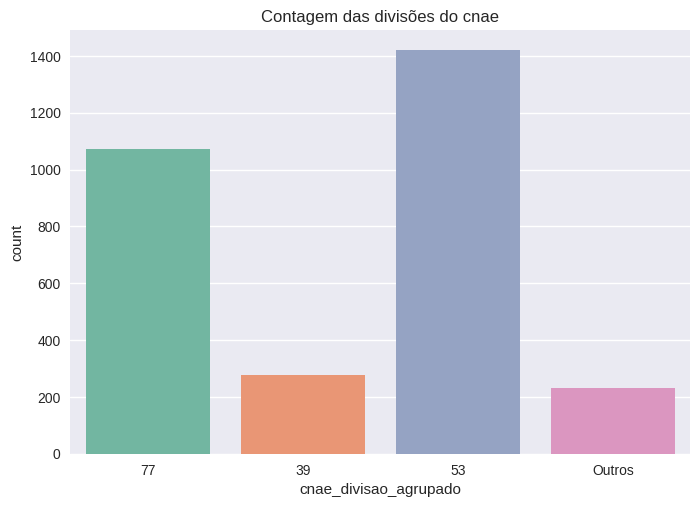

In [ ]:
sns.countplot(data=df1, x='cnae_divisao_agrupado', palette='Set2', hue='cnae_divisao_agrupado', legend=False)
plt.title('Contagem das divisões do cnae')
plt.show()

In [ ]:
contagem_grupos = df1['cnae_grupo'].value_counts()
print(contagem_grupos)

cnae_grupo
532    1143
777     630
398     246
533     220
771     183
773      75
774      61
537      57
778      52
775      38
744      24
772      22
642      20
787      20
391      17
252      15
127      13
776      11
791       9
302       8
334       7
254       6
394       6
335       6
743       5
393       5
129       4
236       4
763       4
361       4
339       4
234       4
761       4
977       4
145       3
251       3
937       3
362       3
799       2
798       2
769       2
141       2
413       2
399       2
973       2
225       2
291       2
762       2
341       2
829       2
965       1
437       1
545       1
455       1
466       1
206       1
934       1
974       1
764       1
814       1
282       1
779       1
861       1
496       1
336       1
889       1
299       1
813       1
475       1
712       1
392       1
935       1
874       1
268       1
477       1
767       1
168       1
419       1
378       1
816       1
786       1
644       1
121  

cnae_grupos_agrupado
532       1143
777        630
Outros     578
398        246
533        220
771        183
Name: count, dtype: int64


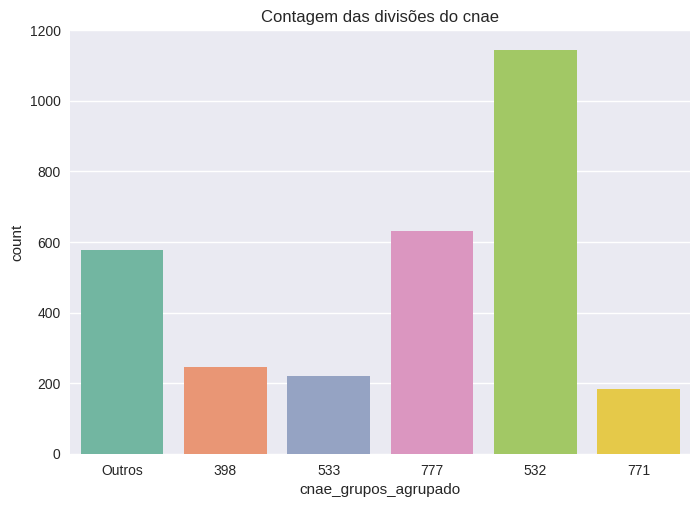

In [ ]:
contagem_grupos = df1['cnae_grupo'].value_counts() # Added to ensure contagem_grupos is defined
threshold = 100
divisoes_para_grupos = contagem_grupos[contagem_grupos < threshold].index

df1["cnae_grupos_agrupado"] = np.where(
    df1["cnae_grupo"].isin(divisoes_para_grupos),
    "Outros",
    df1["cnae_grupo"]
)
print(df1['cnae_grupos_agrupado'].value_counts())

#gráfico
sns.countplot(data=df1, x='cnae_grupos_agrupado', palette='Set2', hue='cnae_grupos_agrupado', legend=False)
plt.title('Contagem das divisões do cnae')
plt.show()

In [ ]:
contagem_classes = df1['cnae_classe'].value_counts()
print(contagem_classes)

cnae_classe
53236    1143
77745     509
39876     246
53351     220
77129     183
         ... 
25411       1
81641       1
78636       1
64447       1
12103       1
Name: count, Length: 111, dtype: int64


cnae_classes_agrupado
53236     1143
Outros     699
77745      509
39876      246
53351      220
77129      183
Name: count, dtype: int64


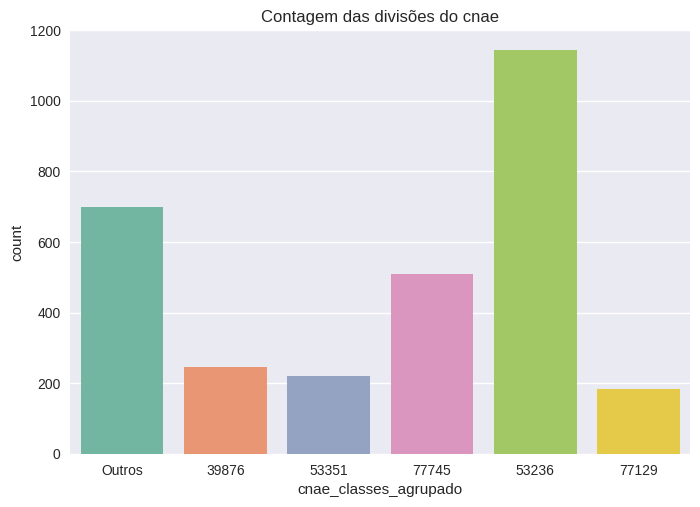

In [ ]:
contagem_classes = df1['cnae_classe'].value_counts() # Corrected 'cnae_classes' to 'cnae_classe'
threshold = 100
divisoes_para_agrupar_classes = contagem_classes[contagem_classes < threshold].index # Corrected variable usage and name

df1["cnae_classes_agrupado"] = np.where(
    df1["cnae_classe"].isin(divisoes_para_agrupar_classes), # Corrected 'cnae_classes' to 'cnae_classe' and used new variable
    "Outros",
    df1["cnae_classe"] # Corrected 'cnae_classes' to 'cnae_classe'
)
print(df1['cnae_classes_agrupado'].value_counts())

#gráfico
sns.countplot(data=df1, x='cnae_classes_agrupado', palette='Set2', hue='cnae_classes_agrupado', legend=False)
plt.title('Contagem das divisões do cnae')
plt.show()

Por questão de especificação em excesso e risco de overfitting decidimos manter a separação com três números.

In [ ]:
df1 = df1.drop(columns = ['cnae_classe','cnae_divisao','cnae_limpo','cnae_codigo','cnae_divisao_agrupado','cnae_classes_agrupado','cnae_grupos_agrupado'])

In [ ]:
df1 = df1.drop(columns={'uf'})

##Separação entre conjunto de teste e treino

Essa etapa é feita antes do encoding para evitar data leakeage

In [ ]:
X_aplicacao = df1.drop('inadimplente', axis=1)
y_aplicacao = df1['inadimplente']

#Estratificação garante que a proporção das classes seja mantida no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(
    X_aplicacao,
    y_aplicacao,
    test_size=0.2,
    stratify=y_aplicacao,
    random_state=42
)

##Encoding

In [ ]:
data_populacao_exemplo = {
    'municipio': [
        'FORTALEZA', 'CAUCAIA', 'MARACANAU', 'EUSEBIO', 'SOBRAL', 'JUAZEIRO DO NORTE',
        'ARACATI', 'HORIZONTE', 'AQUIRAZ', 'PACAJUS', 'PACATUBA', 'CASCAVEL',
        'BEBERIBE', 'MARANGUAPE', 'LIMOEIRO DO NORTE', 'SAO GONCALO DO AMARANTE',
        'ITAITINGA', 'REDENCAO', 'PINDORETAMA', 'GUAIUBA', 'FORTIM', 'ACARAPE',
        'ARACOIABA', 'BATURITE', 'BARREIRA', 'ICAPUI', 'SAO LUIS DO CURU', 'MAURITI',
        'SALITRE', 'JAGUARUANA', 'GUARAMIRANGA', 'CHOROZINHO', 'ITAICABA', 'PARACURU', 'ACARAU'
    ],
    'populacao': [
        2700000, 360000, 230000, 75000, 210000, 280000,
        70000, 65000, 80000, 60000, 90000, 70000,
        55000, 130000, 58000, 60000,
        40000, 30000, 20000, 25000, 15000, 16000,
        26000, 35000, 20000, 20000, 13000, 40000,
        17000, 38000, 4000, 20000, 20000, 35000, 60000
    ]
}

df_populacao = pd.DataFrame(data_populacao_exemplo)

# Definir as faixas de população e seus respectivos códigos
pop_bins = [-np.inf, 50000, 500000, np.inf] # Limites das faixas: <50k, 50k-500k, >500k
pop_labels = [1, 2, 3] # 1=Baixa, 2=Média, 3=Alta

df_pop_temp = df_populacao.copy()

df_pop_temp['pop_encoded'] = pd.cut(
    df_pop_temp['populacao'],
    bins=pop_bins,
    labels=pop_labels,
    right=False,
    ordered=False
).astype(int)

municipio_pop_encoding = dict(zip(df_pop_temp['municipio'], df_pop_temp['pop_encoded']))

if 'municipio' not in X_train.columns:
    X_train = X_train.join(df1[['municipio']], how='left')
if 'municipio' not in X_test.columns:
    X_test = X_test.join(df1[['municipio']], how='left')


all_municipalities_in_data = pd.concat([X_train['municipio'], X_test['municipio']]).unique()

for mun in all_municipalities_in_data:
    if mun not in municipio_pop_encoding:
        municipio_pop_encoding[mun] = 0

print("Dicionário de encoding de município por faixa de População criado:")
display(municipio_pop_encoding)


X_train['municipio_pop_encoded'] = X_train['municipio'].map(municipio_pop_encoding)
X_test['municipio_pop_encoded'] = X_test['municipio'].map(municipio_pop_encoding)


X_train = X_train.drop('municipio', axis=1)
X_test = X_test.drop('municipio', axis=1)

print("\nEncoding de população aplicado na coluna 'municipio' para X_train e X_test.")
print(f"Novas dimensões de X_train: {X_train.shape}")
print(f"Novas dimensões de X_test: {X_test.shape}")
print("\nPrimeiras linhas de X_train com a nova coluna 'municipio_pop_encoded':")
display(X_train[['municipio_pop_encoded']].head())

Dicionário de encoding de município por faixa de População criado:


{'FORTALEZA': 3,
 'CAUCAIA': 2,
 'MARACANAU': 2,
 'EUSEBIO': 2,
 'SOBRAL': 2,
 'JUAZEIRO DO NORTE': 2,
 'ARACATI': 2,
 'HORIZONTE': 2,
 'AQUIRAZ': 2,
 'PACAJUS': 2,
 'PACATUBA': 2,
 'CASCAVEL': 2,
 'BEBERIBE': 2,
 'MARANGUAPE': 2,
 'LIMOEIRO DO NORTE': 2,
 'SAO GONCALO DO AMARANTE': 2,
 'ITAITINGA': 1,
 'REDENCAO': 1,
 'PINDORETAMA': 1,
 'GUAIUBA': 1,
 'FORTIM': 1,
 'ACARAPE': 1,
 'ARACOIABA': 1,
 'BATURITE': 1,
 'BARREIRA': 1,
 'ICAPUI': 1,
 'SAO LUIS DO CURU': 1,
 'MAURITI': 1,
 'SALITRE': 1,
 'JAGUARUANA': 1,
 'GUARAMIRANGA': 1,
 'CHOROZINHO': 1,
 'ITAICABA': 1,
 'PARACURU': 1,
 'ACARAU': 2,
 'PACOTI': 0}


Encoding de população aplicado na coluna 'municipio' para X_train e X_test.
Novas dimensões de X_train: (2400, 14)
Novas dimensões de X_test: (600, 14)

Primeiras linhas de X_train com a nova coluna 'municipio_pop_encoded':


,municipio_pop_encoded
472,2
1542,3
871,3
988,2
2995,3


Como cada algoritimo precisa de um tratamento e encoding diferente, criamos copias do treino e teste para trata-los individualmente para cada algoritmo

In [ ]:
# Treino e teste da Regressão Logística
X_train_RegLog = X_train.copy()
X_test_RegLog = X_test.copy()

# Treino e teste da Random Forest
X_train_RandForest = X_train.copy()
X_test_RandForest = X_test.copy()

# Treino e teste do KNN
X_train_Knn = X_train.copy()
X_test_Knn = X_test.copy()

Primeiramente, algumas colunas, como capital_social, possuem intervalos ao invés de numeros, vamos transformar todos on intervalos em seus pontos médios, ex '[500, 1000)' em 750. Os algoritmos KNN e Regressão Logistica precisam disso para funcionar, enquanto a Random Forest se beneficia pois cria uma ordem numérica crescente, o que facilita a separação dos intervalos.

In [ ]:

def calculate_midpoint(interval_str):

    if pd.isna(interval_str):
        return interval_str


    vx, vy = str(interval_str).split(', ')


    vx = float(vx[1:])
    vy = float(vy[:-1])


    return (vx + vy) / 2


def apply_midpoints(df_train, df_test, columns):

    for col in columns:
        if col in df_train.columns:
            df_train[col] = df_train[col].apply(calculate_midpoint)
        if col in df_test.columns:
            df_test[col] = df_test[col].apply(calculate_midpoint)

    return df_train, df_test



In [ ]:
# The columns you want to transform
cols_intervalos = ['capital_social', 'idade_cnpj', 'ifood_contagem_avaliacoes', 'google_maps_contagem_avaliacoes', 'valor', 'atraso']

# Transform Random Forest datasets
X_train_RandForest, X_test_RandForest = apply_midpoints(X_train_RandForest, X_test_RandForest, cols_intervalos)

# Transform Logistic Regression datasets
X_train_RegLog, X_test_RegLog = apply_midpoints(X_train_RegLog, X_test_RegLog, cols_intervalos)

# Transform KNN datasets
X_train_Knn, X_test_Knn = apply_midpoints(X_train_Knn, X_test_Knn, cols_intervalos)

Agora, temos o encoding de variaveis nominais. Esse encoding é mais especifico para cada algoritmo, já que fazendo um encoding numerico o KNN e a regreção logistica criam uma ideia de ordem

Random Forest:

In [ ]:
from sklearn.preprocessing import OrdinalEncoder


cols_nominais = [
    'segmento_cliente',
    'natureza_juridica',
    'fonte_cliente'
]


encoder_rf = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)


X_train_RandForest[cols_nominais] = encoder_rf.fit_transform(X_train_RandForest[cols_nominais])
X_test_RandForest[cols_nominais] = encoder_rf.transform(X_test_RandForest[cols_nominais])

Para o KNN e reg Logistica, vamos usar um one hot, porem como algumas colunas tem muitos valores criamos uma função que pega os N valores mais comuns e transforam os demais valores na categoria 'outros'

In [ ]:
def encode_top_n_onehot(df_train, df_test, col, top_n=5):
    top_categories = df_train[col].value_counts().nlargest(top_n).index

    df_train[col] = df_train[col].where(df_train[col].isin(top_categories), 'Outros')
    df_test[col]  = df_test[col].where(df_test[col].isin(top_categories), 'Outros')

    train_dummies = pd.get_dummies(df_train[col], prefix=col, dtype=int)
    test_dummies  = pd.get_dummies(df_test[col], prefix=col, dtype=int)


    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)


    df_train = pd.concat([df_train, train_dummies], axis=1)
    df_test  = pd.concat([df_test, test_dummies], axis=1)


    df_train = df_train.drop(columns=[col])
    df_test  = df_test.drop(columns=[col])

    return df_train, df_test

In [ ]:
cols_nominais_top_n = [
    ('segmento_cliente', 7),   # Keeps the top 7 segments, groups the rest
    ('natureza_juridica', 3),  # Keeps all of them
    ('fonte_cliente', 4)       # Keeps all of them
]


for col, n in cols_nominais_top_n:

    # Apply to Logistic Regression datasets
    X_train_RegLog, X_test_RegLog = encode_top_n_onehot(
        X_train_RegLog,
        X_test_RegLog,
        col,
        top_n=n
    )

    # Apply to KNN datasets
    X_train_Knn, X_test_Knn = encode_top_n_onehot(
        X_train_Knn,
        X_test_Knn,
        col,
        top_n=n
    )

In [ ]:
def codificar_multilabel_top_n(df_train, df_test, coluna, top_n=10):

    df_train[coluna] = df_train[coluna].fillna('Desconhecido')
    df_test[coluna]  = df_test[coluna].fillna('Desconhecido')


    train_dummies = df_train[coluna].str.get_dummies(sep=', ')
    test_dummies  = df_test[coluna].str.get_dummies(sep=', ')


    top_tags = train_dummies.sum().nlargest(top_n).index.tolist()


    rare_cols_train = [c for c in train_dummies.columns if c not in top_tags]
    if rare_cols_train:

        train_dummies['Outros'] = (train_dummies[rare_cols_train].sum(axis=1) > 0).astype(int)
        train_dummies = train_dummies.drop(columns=rare_cols_train)
    else:
        train_dummies['Outros'] = 0


    rare_cols_test = [c for c in test_dummies.columns if c not in top_tags]
    if rare_cols_test:
        test_dummies['Outros'] = (test_dummies[rare_cols_test].sum(axis=1) > 0).astype(int)
        test_dummies = test_dummies.drop(columns=rare_cols_test)
    else:
        test_dummies['Outros'] = 0


    train_dummies = train_dummies.add_prefix(f'{coluna}_')
    test_dummies  = test_dummies.add_prefix(f'{coluna}_')


    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)


    df_train = pd.concat([df_train, train_dummies], axis=1)
    df_test  = pd.concat([df_test, test_dummies], axis=1)

    df_train = df_train.drop(columns=[coluna])
    df_test  = df_test.drop(columns=[coluna])

    return df_train, df_test

In [ ]:
coluna_setores = 'serasa_credores'
top_n_escolhido = 8

# 1. Random Forest
X_train_RandForest, X_test_RandForest = codificar_multilabel_top_n(
    X_train_RandForest, X_test_RandForest, coluna_setores, top_n=top_n_escolhido
)

# 2. Logistic Regression
X_train_RegLog, X_test_RegLog = codificar_multilabel_top_n(
    X_train_RegLog, X_test_RegLog, coluna_setores, top_n=top_n_escolhido
)

# 3. KNN
X_train_Knn, X_test_Knn = codificar_multilabel_top_n(
    X_train_Knn, X_test_Knn, coluna_setores, top_n=top_n_escolhido
)

##Normalização

In [ ]:
print(X_train_Knn.dtypes)

id_cliente                                                                                              int64
capital_social                                                                                        float64
idade_cnpj                                                                                            float64
serasa_contagem_negativacoes                                                                          float64
serasa_contagem_protestos                                                                             float64
serasa_socio_tem_negativacao                                                                          float64
tem_google_maps                                                                                         int64
tem_ifood                                                                                               int64
cnae_grupo                                                                                             object
municipio_

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler_knn = StandardScaler()
scaler_lr = StandardScaler()

#KNN
X_train_Knn_scaled = pd.DataFrame(
    scaler_knn.fit_transform(X_train_Knn),
    columns=X_train_Knn.columns,
    index=X_train_Knn.index
)


X_test_Knn_scaled = pd.DataFrame(
    scaler_knn.transform(X_test_Knn),
    columns=X_test_Knn.columns,
    index=X_test_Knn.index
)

# RegLog
X_train_RegLog_scaled = pd.DataFrame(
    scaler_lr.fit_transform(X_train_RegLog),
    columns=X_train_RegLog.columns,
    index=X_train_RegLog.index
)

X_test_RegLog_scaled = pd.DataFrame(
    scaler_lr.transform(X_test_RegLog),
    columns=X_test_RegLog.columns,
    index=X_test_RegLog.index
)

#PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
pca = PCA(n_components=0.90, random_state=42)

X_train_pca_reg_log = pca.fit_transform(X_train_RegLog_scaled)
X_test_pca_rec_log  = pca.transform(X_test_RegLog_scaled)

X_train_pca_knn = pca.fit_transform(X_train_Knn_scaled)
X_test_pca_knn  = pca.transform(X_test_Knn_scaled)

# Regressão Logística

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_pca_reg_log, y_train)

y_pred_lr = lr.predict(X_test_pca_rec_log)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Logistic Regression: 0.74


# Regressão Logística sem PCA

In [ ]:
colunas_continuas = ['capital_social']

pre_processador = ColumnTransformer(
    transformers=[
        ('kbins', KBinsDiscretizer(encode='onehot-dense', strategy='quantile'), colunas_continuas)
    ],
    remainder='passthrough'
)

lr_pipe_bins = Pipeline([
    ('pre_processador', pre_processador),
    ('balanceamento', SMOTE(random_state=42)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

param_grid_lr_bins = {
    'pre_processador__kbins__n_bins': [3, 5, 8],
    'balanceamento': [SMOTE(random_state=42), RandomUnderSampler(random_state=42),],
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear']
}

grid_lr_bins = GridSearchCV(
    estimator=lr_pipe_bins,
    param_grid=param_grid_lr_bins,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Iniciando o tuning com KBinsDiscretizer (Foco em F1-Score)")
grid_lr_bins.fit(X_train_RegLog, y_train)

modelo_lr_final = grid_lr_bins.best_estimator_

print("\nRESULTADO DO TUNING (LOGISTIC REGRESSION + BINS):")
print(f"Melhor configuração: {grid_lr_bins.best_params_}")
print(f"Melhor F1-Score no Treino: {grid_lr_bins.best_score_:.4f}")

Iniciando o tuning com KBinsDiscretizer (Foco em F1-Score)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

RESULTADO DO TUNING (LOGISTIC REGRESSION + BINS):
Melhor configuração: {'balanceamento': SMOTE(random_state=42), 'lr__C': 1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear', 'pre_processador__kbins__n_bins': 8}
Melhor F1-Score no Treino: 0.7512


In [ ]:
y_pred_lr_bins = modelo_lr_final.predict(X_test_RegLog)


precision_lr = precision_score(y_test, y_pred_lr_bins)
recall_lr = recall_score(y_test, y_pred_lr_bins)
f1_lr = f1_score(y_test, y_pred_lr_bins)



print("MÉTRICAS: REGRESSÃO LOGÍSTICA\n")
print(f"Precision (Precisão):     {precision_lr:.4f}")
print(f"Recall (Sensibilidade):   {recall_lr:.4f}")
print(f"F1-Score:                 {f1_lr:.4f}")

MÉTRICAS: REGRESSÃO LOGÍSTICA

Precision (Precisão):     0.5078
Recall (Sensibilidade):   0.6915
F1-Score:                 0.5856


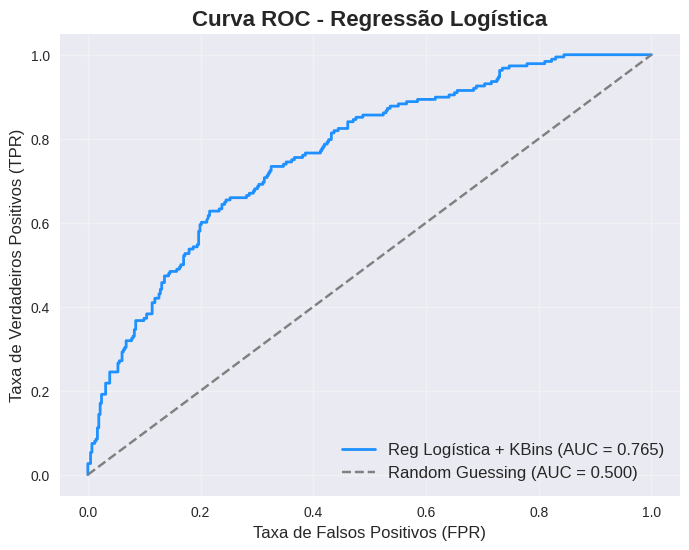

In [ ]:
prob_lr_bins = modelo_lr_final.predict_proba(X_test_RegLog)[:, 1]


auc_lr_bins = roc_auc_score(y_test, prob_lr_bins)
fpr_lr_bins, tpr_lr_bins, _ = roc_curve(y_test, prob_lr_bins)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr_bins, tpr_lr_bins, label=f'Reg Logística + KBins (AUC = {auc_lr_bins:.3f})', linewidth=2, color='dodgerblue')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - Regressão Logística', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# Random Forest

In [ ]:
#Não usa PCA
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_RandForest, y_train)

y_pred = rf.predict(X_test_RandForest)
print("Random Forest", accuracy_score(y_test, y_pred))

Random Forest 0.7416666666666667


In [ ]:
rf_pipe_dinamico = Pipeline([
    ('balanceamento', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True))
])

param_grid_rf_dinamico = {
    'balanceamento': [
        SMOTE(random_state=42),
        RandomUnderSampler(random_state=42),
        'passthrough'
    ],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 10],
    'rf__class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    estimator=rf_pipe_dinamico,
    param_grid=param_grid_rf_dinamico,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

print("Iniciando o treinamento")
grid_rf.fit(X_train_RandForest, y_train)

modelo_rf_otimizado = grid_rf.best_estimator_

print("RANDOM FOREST TUNING RESULTS:")
print(f"Melhor Configuração: {grid_rf.best_params_}")
print(f"Melhor AUC-ROC no Treino: {grid_rf.best_score_:.4f}")

rf_vencedora = modelo_rf_otimizado.named_steps['rf']

oob_accuracy = rf_vencedora.oob_score_

oob_error = 1 - oob_accuracy

print("\nMÉTRICAS OUT-OF-BAG (OOB):")
print(f"OOB Score (Acurácia simulada): {oob_accuracy:.4f}")
print(f"OOB Error (Taxa de Erro):      {oob_error:.4f} (ou {oob_error * 100:.2f}%)")

Iniciando o treinamento
Fitting 5 folds for each of 72 candidates, totalling 360 fits
RANDOM FOREST TUNING RESULTS:
Melhor Configuração: {'balanceamento': 'passthrough', 'rf__class_weight': None, 'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Melhor AUC-ROC no Treino: 0.7710

MÉTRICAS OUT-OF-BAG (OOB):
OOB Score (Acurácia simulada): 0.7338
OOB Error (Taxa de Erro):      0.2662 (ou 26.62%)


In [ ]:
y_pred_rf = modelo_rf_otimizado.predict(X_test_RandForest)

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("MÉTRICAS DA RANDOM FOREST OTIMIZADA:")
print(f"Precision (Precisão):     {precision_rf:.4f}")
print(f"Recall (Sensibilidade):   {recall_rf:.4f}")
print(f"F1-Score:                 {f1_rf:.4f}")

MÉTRICAS DA RANDOM FOREST OTIMIZADA:
Precision (Precisão):     0.7143
Recall (Sensibilidade):   0.3989
F1-Score:                 0.5119


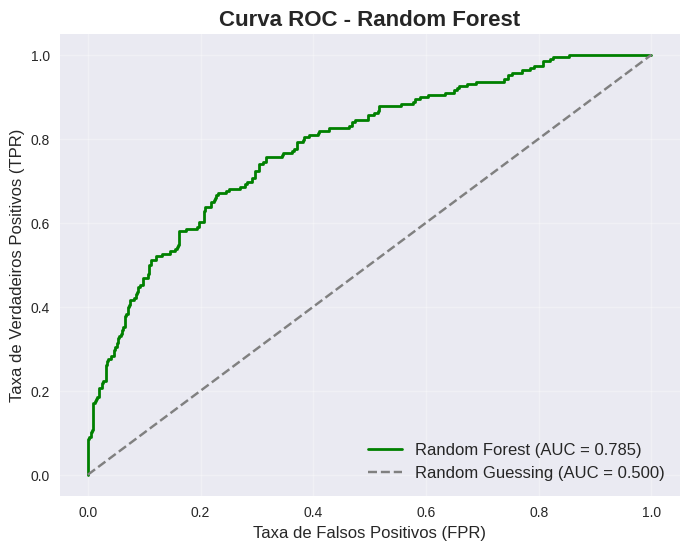

In [ ]:
prob_rf = modelo_rf_otimizado.predict_proba(X_test_RandForest)[:, 1]

auc_rf = roc_auc_score(y_test, prob_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2, color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# HistGradientBoosting

In [ ]:
colunas_nominais = ['natureza_juridica', 'segmento_cliente', 'fonte_cliente']

for col in colunas_nominais:
    X_train_RandForest[col] = X_train_RandForest[col].astype('category')

    categorias_do_treino = X_train_RandForest[col].cat.categories
    X_test_RandForest[col] = X_test_RandForest[col].astype(pd.CategoricalDtype(categories=categorias_do_treino))



hgb_pipe = Pipeline([
    ('balanceamento', RandomUnderSampler(random_state=42)),
    ('hgb', HistGradientBoostingClassifier(
        categorical_features='from_dtype',
        random_state=42
    ))
])

param_grid_hgb = {
    'balanceamento': [RandomUnderSampler(random_state=42)],

    'hgb__learning_rate': [0.01, 0.05, 0.1, 0.6],

    'hgb__max_iter': [100, 200, 400, 700],

    'hgb__max_depth': [3, 5],

    'hgb__l2_regularization': [0.0, 1.0]
}

grid_hgb = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid_hgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

print("Iniciando o Tuning do HistGradientBoosting")
grid_hgb.fit(X_train_RandForest, y_train)

modelo_tree_avancado = grid_hgb.best_estimator_

print("\nRESULTADO DO TUNING DO HIST GRADIENT BOOSTING")
print(f"Melhor configuração: {grid_hgb.best_params_}")
print(f"Melhor AUC-ROC no Treino: {grid_hgb.best_score_:.4f}")

Iniciando o Tuning do HistGradientBoosting
Fitting 5 folds for each of 64 candidates, totalling 320 fits

RESULTADO DO TUNING DO HIST GRADIENT BOOSTING
Melhor configuração: {'balanceamento': RandomUnderSampler(random_state=42), 'hgb__l2_regularization': 0.0, 'hgb__learning_rate': 0.05, 'hgb__max_depth': 3, 'hgb__max_iter': 100}
Melhor AUC-ROC no Treino: 0.7586


In [ ]:
y_pred_tree = modelo_tree_avancado.predict(X_test_RandForest)

precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("MÉTRICAS: HIST GRADIENT BOOSTING (CATEGORIAS):")
print(f"Precision (Precisão):     {precision_tree:.4f}")
print(f"Recall (Sensibilidade):   {recall_tree:.4f}")
print(f"F1-Score:                 {f1_tree:.4f}")

MÉTRICAS: HIST GRADIENT BOOSTING (CATEGORIAS):
Precision (Precisão):     0.5339
Recall (Sensibilidade):   0.7128
F1-Score:                 0.6105


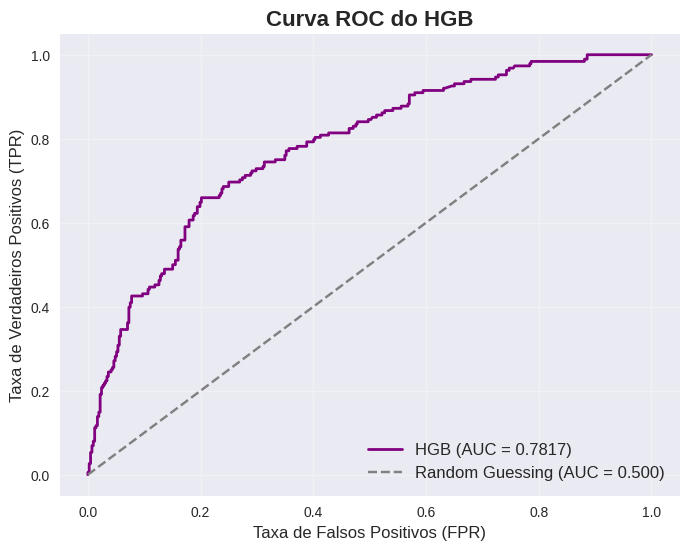

In [ ]:
prob_teste_real = modelo_tree_avancado.predict_proba(X_test_RandForest)[:, 1]
auc_teste_real = roc_auc_score(y_test, prob_teste_real)

fpr_real, tpr_real, _ = roc_curve(y_test, prob_teste_real)

plt.figure(figsize=(8, 6))
plt.plot(fpr_real, tpr_real, label=f'HGB (AUC = {auc_teste_real:.4f})', linewidth=2, color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC do HGB', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
resultado = permutation_importance(
    modelo_tree_avancado,
    X_test_RandForest,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42
)

importancias = pd.DataFrame({
    'Variavel': X_test_RandForest.columns,
    'Importancia': resultado.importances_mean
}).sort_values(by='Importancia', ascending=False)

print("Top 5 Variáveis Mais Importantes para o Modelo:")
print(importancias.head(5))

Top 5 Variáveis Mais Importantes para o Modelo:
                               Variavel  Importancia
5                            idade_cnpj     0.107584
8          serasa_socio_tem_negativacao     0.045262
1                      segmento_cliente     0.029075
13  serasa_credores_Alimentos e Bebidas     0.017696
3                         fonte_cliente     0.016203


# HBC Regressor

In [ ]:

hgb_pipe_reg = Pipeline([
    ('hgb', HistGradientBoostingRegressor(
        categorical_features='from_dtype',
        random_state=42
    ))
])

param_grid_hgb_reg = {
    'hgb__learning_rate': [0.01, 0.05, 0.1],
    'hgb__max_iter': [100, 200, 300],
    'hgb__max_depth': [3, 5, None],
    'hgb__l2_regularization': [0.0, 1.0]
}

grid_hgb_reg = GridSearchCV(
    estimator=hgb_pipe_reg,
    param_grid=param_grid_hgb_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

print("Iniciando o Tuning do HistGradientBoosting Regressor")
grid_hgb_reg.fit(X_train_RandForest, y_train)

modelo_hgb_reg_otimizado = grid_hgb_reg.best_estimator_

print("\nRESULTADO DO TUNING DO HGB REGRESSOR")
print(f"Melhor configuração: {grid_hgb_reg.best_params_}")
print(f"Melhor R² no Treino: {grid_hgb_reg.best_score_:.4f}")

Iniciando o Tuning do HistGradientBoosting Regressor
Fitting 5 folds for each of 54 candidates, totalling 270 fits

RESULTADO DO TUNING DO HGB REGRESSOR
Melhor configuração: {'hgb__l2_regularization': 1.0, 'hgb__learning_rate': 0.05, 'hgb__max_depth': 3, 'hgb__max_iter': 100}
Melhor R² no Treino: 0.1766


MÉTRICAS: HIST GRADIENT BOOSTING REGRESSOR:
MAE (Erro Absoluto Médio):       0.3483
RMSE (Erro Quadrático Médio):    0.4114
R-quadrado (R²):                 0.2134


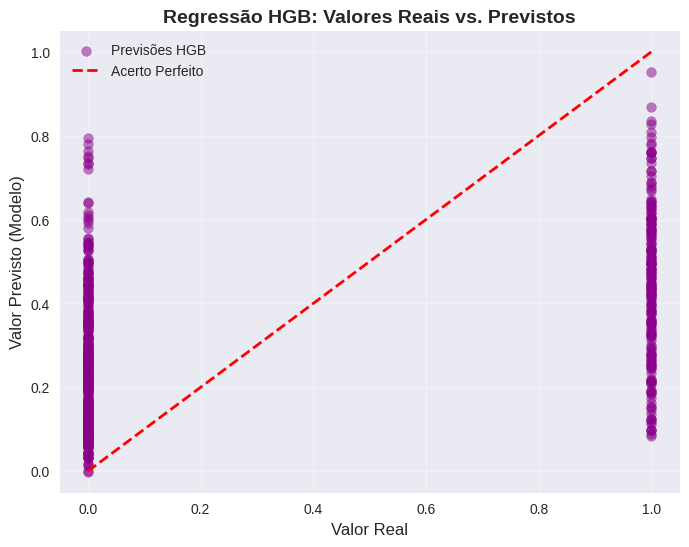

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_hgb_reg = modelo_hgb_reg_otimizado.predict(X_test_RandForest)

mae_hgb = mean_absolute_error(y_test, y_pred_hgb_reg)
rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb_reg))
r2_hgb = r2_score(y_test, y_pred_hgb_reg)

print("MÉTRICAS: HIST GRADIENT BOOSTING REGRESSOR:")
print(f"MAE (Erro Absoluto Médio):       {mae_hgb:.4f}")
print(f"RMSE (Erro Quadrático Médio):    {rmse_hgb:.4f}")
print(f"R-quadrado (R²):                 {r2_hgb:.4f}")


plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_hgb_reg, alpha=0.5, color='darkmagenta', label='Previsões HGB')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2, label='Acerto Perfeito')

plt.title('Regressão HGB: Valores Reais vs. Previstos', fontsize=14, fontweight='bold')
plt.xlabel('Valor Real', fontsize=12)
plt.ylabel('Valor Previsto (Modelo)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

# XG Boost

In [ ]:
colunas_nominais = ['natureza_juridica', 'segmento_cliente', 'fonte_cliente']

for col in colunas_nominais:
    X_train_RandForest[col] = X_train_RandForest[col].astype(str).astype('category')
    X_test_RandForest[col]  = X_test_RandForest[col].astype(str).astype('category')

print("Limpeza de categorias concluída! O XGBoost já pode rodar.")

Limpeza de categorias concluída! O XGBoost já pode rodar.


In [ ]:
colunas_categoricas = X_train_RandForest.select_dtypes(include=['category']).columns
colunas_categoricas_adicionais = ['cnae_grupo']

for col in colunas_categoricas:
    categorias_treino_str = X_train_RandForest[col].cat.categories.astype(str)
    X_train_RandForest[col] = X_train_RandForest[col].cat.rename_categories(categorias_treino_str)

    categorias_teste_str = X_test_RandForest[col].cat.categories.astype(str)
    X_test_RandForest[col] = X_test_RandForest[col].cat.rename_categories(categorias_teste_str)

for col in colunas_categoricas_adicionais:
    if col in X_train_RandForest.columns:
        X_train_RandForest[col] = X_train_RandForest[col].astype('category')
    if col in X_test_RandForest.columns:
        X_test_RandForest[col] = X_test_RandForest[col].astype('category')

print(f"Metadados corrigidos nas colunas: {list(colunas_categoricas)}")
print(f"Colunas adicionais convertidas para category: {colunas_categoricas_adicionais}")

Metadados corrigidos nas colunas: ['segmento_cliente', 'natureza_juridica', 'fonte_cliente']
Colunas adicionais convertidas para category: ['cnae_grupo']


In [ ]:

xgb_pipe = Pipeline([
    ('balanceamento', RandomUnderSampler(random_state=42)),
    ('xgb', XGBClassifier(
        enable_categorical=True,
        tree_method='hist',
        random_state=42,
        eval_metric='auc',
        n_jobs=-1
    ))
])

param_grid_xgb = {
    'balanceamento': [RandomUnderSampler(random_state=42), 'passthrough'],

    'xgb__n_estimators': [100, 200],

    'xgb__max_depth': [3, 5],

    'xgb__learning_rate': [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Iniciando o tuning rápido do XGBoost")
grid_xgb.fit(X_train_RandForest, y_train)

modelo_xgb_otimizado = grid_xgb.best_estimator_

print("\nRESULTADO DO TUNING DO XGBOOST ")
print(f"Melhor configuração: {grid_xgb.best_params_}")
print(f"Melhor AUC-ROC no Treino: {grid_xgb.best_score_:.4f}")

Iniciando o tuning rápido do XGBoost
Fitting 5 folds for each of 16 candidates, totalling 80 fits

RESULTADO DO TUNING DO XGBOOST 
Melhor configuração: {'balanceamento': 'passthrough', 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Melhor AUC-ROC no Treino: 0.7671


In [ ]:

y_pred_xgb = modelo_xgb_otimizado.predict(X_test_RandForest)

precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("MÉTRICAS: XGBOOST OTIMIZADO")
print(f"Precision (Precisão):     {precision_xgb:.4f}")
print(f"Recall (Sensibilidade):   {recall_xgb:.4f}")
print(f"F1-Score:                 {f1_xgb:.4f}")

MÉTRICAS: XGBOOST OTIMIZADO
Precision (Precisão):     0.6618
Recall (Sensibilidade):   0.4787
F1-Score:                 0.5556


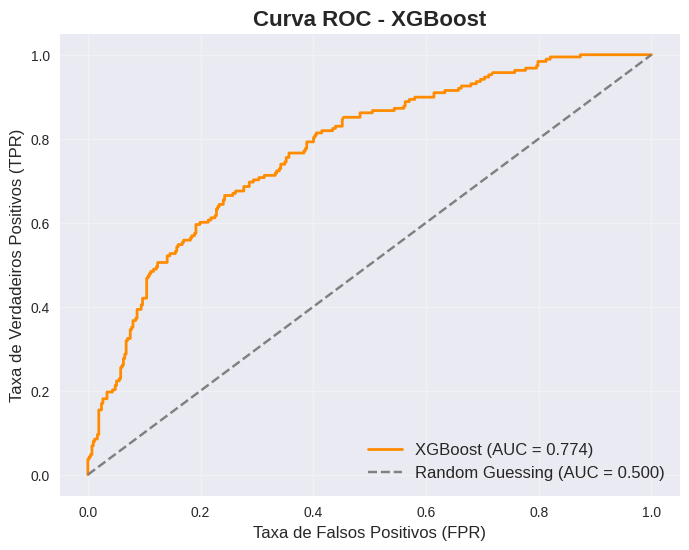

In [ ]:

prob_xgb = modelo_xgb_otimizado.predict_proba(X_test_RandForest)[:, 1]

auc_xgb = roc_auc_score(y_test, prob_xgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', linewidth=2, color='darkorange')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - XGBoost', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# XG Boosting Regressão

In [ ]:
#REGRESSÃO
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb_pipe_reg = Pipeline([
    ('xgb', XGBRegressor(
        enable_categorical=True,
        tree_method='hist',
        random_state=42,
        eval_metric='rmse',
        n_jobs=-1
    ))
])

param_grid_xgb_reg = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.05, 0.1]
}

grid_xgb_reg = GridSearchCV(
    estimator=xgb_pipe_reg,
    param_grid=param_grid_xgb_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Iniciando o tuning rápido do XGBoost Regressor")
grid_xgb_reg.fit(X_train_RandForest, y_train)

modelo_xgb_reg_otimizado = grid_xgb_reg.best_estimator_

print("\nRESULTADO DO TUNING DO XGBOOST REGRESSOR")
print(f"Melhor configuração: {grid_xgb_reg.best_params_}")
print(f"Melhor R² no Treino (Cross-Validation): {grid_xgb_reg.best_score_:.4f}")

Iniciando o tuning rápido do XGBoost Regressor
Fitting 5 folds for each of 8 candidates, totalling 40 fits

RESULTADO DO TUNING DO XGBOOST REGRESSOR
Melhor configuração: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Melhor R² no Treino (Cross-Validation): 0.1609


MÉTRICAS: XGBOOST REGRESSOR
MAE (Erro Absoluto Médio):       0.3494
RMSE (Erro Quadrático Médio):    0.4151
R-quadrado (R²):                 0.1992


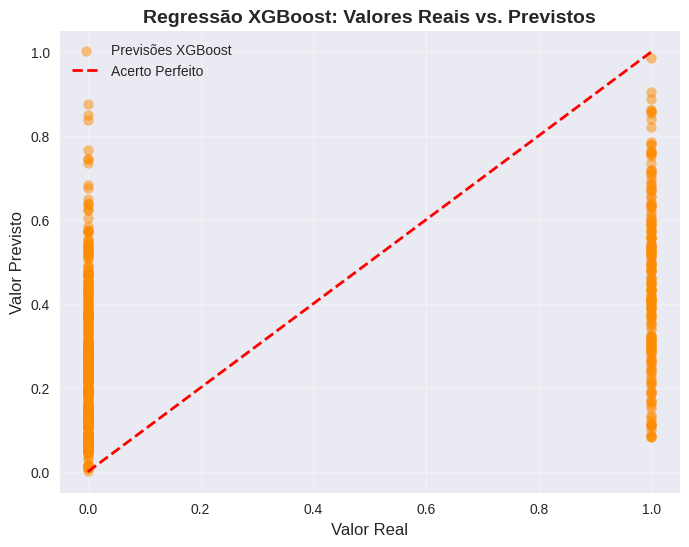

In [ ]:


y_pred_xgb_reg = modelo_xgb_reg_otimizado.predict(X_test_RandForest)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb_reg)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_reg))
r2_xgb = r2_score(y_test, y_pred_xgb_reg)

print("MÉTRICAS: XGBOOST REGRESSOR")
print(f"MAE (Erro Absoluto Médio):       {mae_xgb:.4f}")
print(f"RMSE (Erro Quadrático Médio):    {rmse_xgb:.4f}")
print(f"R-quadrado (R²):                 {r2_xgb:.4f}")

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_xgb_reg, alpha=0.5, color='darkorange', label='Previsões XGBoost')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2, label='Acerto Perfeito')

plt.title('Regressão XGBoost: Valores Reais vs. Previstos', fontsize=14, fontweight='bold')
plt.xlabel('Valor Real', fontsize=12)
plt.ylabel('Valor Previsto', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

# KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca_knn, y_train)

y_pred_knn = knn.predict(X_test_pca_knn)
print("KNN:", accuracy_score(y_test, y_pred_knn))

KNN: 0.6983333333333334


In [ ]:
# estava tendo um conflito com o Pipeline do sklearn
from imblearn.pipeline import Pipeline as ImbPipeline

knn_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid_knn,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Iniciando o tuning do KNN Classificador...")
grid_knn.fit(X_train_Knn_scaled, y_train)


modelo_knn_clf_otimizado = grid_knn.best_estimator_
print(f"\nMelhores Parâmetros: {grid_knn.best_params_}")


y_pred_knn = modelo_knn_clf_otimizado.predict(X_test_Knn_scaled)
prob_knn = modelo_knn_clf_otimizado.predict_proba(X_test_Knn_scaled)[:, 1]

print("\n--- Resultados no Teste ---")
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"KNN AUC-ROC:  {roc_auc_score(y_test, prob_knn):.4f}")

Iniciando o tuning do KNN Classificador...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores Parâmetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}

--- Resultados no Teste ---
KNN Accuracy: 0.6450
KNN AUC-ROC:  0.6875


In [ ]:

y_pred_knn = modelo_knn_clf_otimizado.predict(X_test_Knn_scaled)

precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)

print("MÉTRICAS DO KNN OTIMIZADO")
print(f"Precision (Precisão):     {precision:.4f}")
print(f"Recall (Sensibilidade):   {recall:.4f}")
print(f"F1-Score:                 {f1:.4f}")

MÉTRICAS DO KNN OTIMIZADO
Precision (Precisão):     0.4490
Recall (Sensibilidade):   0.5851
F1-Score:                 0.5081


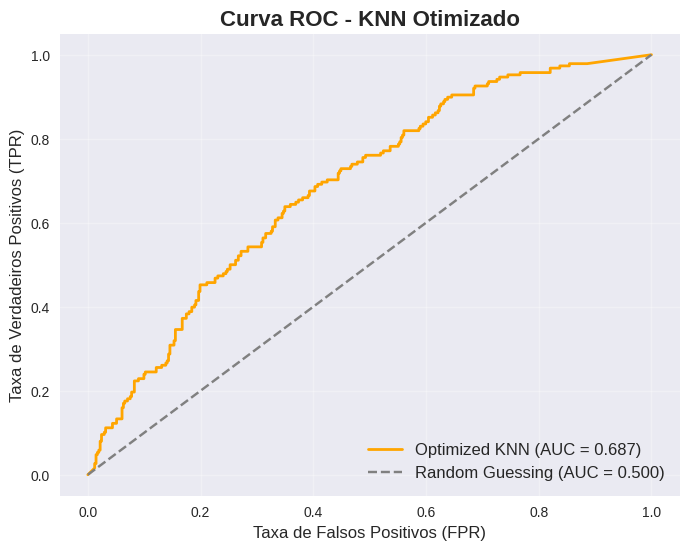

In [ ]:

prob_knn = modelo_knn_clf_otimizado.predict_proba(X_test_Knn_scaled)[:, 1]

auc_knn = roc_auc_score(y_test, prob_knn)
fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)

plt.figure(figsize=(8, 6))

plt.plot(fpr_knn, tpr_knn, label=f'Optimized KNN (AUC = {auc_knn:.3f})', linewidth=2, color='orange')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - KNN Otimizado', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:

knn_pipe = Pipeline([
    ('knn', KNeighborsRegressor())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Iniciando o tuning do KNN Regressor...")
grid_knn.fit(X_train_Knn_scaled, y_train)

modelo_knn_otimizado = grid_knn.best_estimator_
print(f"\nMelhores Parâmetros: {grid_knn.best_params_}")

y_pred_knn = modelo_knn_otimizado.predict(X_test_Knn_scaled)

mae = mean_absolute_error(y_test, y_pred_knn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2 = r2_score(y_test, y_pred_knn)

print("\n--- Resultados no Teste (Regressão) ---")
print(f"MAE (Erro Médio Absoluto):  {mae:.4f}")
print(f"RMSE (Erro Quadrático Médio): {rmse:.4f}")
print(f"R-quadrado (R²):            {r2:.4f}")

Iniciando o tuning do KNN Regressor...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores Parâmetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}

--- Resultados no Teste (Regressão) ---
MAE (Erro Médio Absoluto):  0.3626
RMSE (Erro Quadrático Médio): 0.4365
R-quadrado (R²):            0.1145


# SVC

In [ ]:
# estava tendo um conflito com o Pipeline do sklearn
from imblearn.pipeline import Pipeline as ImbPipeline

svc_pipe = ImbPipeline([
    ('balanceamento', SMOTE(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
])

param_grid_svc = {
    'balanceamento': [SMOTE(random_state=42), RandomUnderSampler(random_state=42)],
    'svc__C': [0.1, 1, 10, 50],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(
    estimator=svc_pipe,
    param_grid=param_grid_svc,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=3
)

print("Iniciando o tuning COMPLETO do SVC")
grid_svc.fit(X_train_RegLog_scaled, y_train)

modelo_svc_otimizado = grid_svc.best_estimator_

print("\n=== RESULTADO DO TUNING DO SVC ===")
print(f"Melhor configuração: {grid_svc.best_params_}")
print(f"Melhor AUC-ROC no Treino: {grid_svc.best_score_:.4f}")

Iniciando o tuning COMPLETO do SVC
Fitting 5 folds for each of 32 candidates, totalling 160 fits

=== RESULTADO DO TUNING DO SVC ===
Melhor configuração: {'balanceamento': SMOTE(random_state=42), 'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Melhor AUC-ROC no Treino: 0.7460


In [ ]:

# 1. Previsões rígidas (0 ou 1)
y_pred_svc = modelo_svc_otimizado.predict(X_test_RegLog_scaled)

# 2. Cálculos
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)


print("MÉTRICAS: SUPPORT VECTOR CLASSIFIER (SVC):")
print(f"Precision (Precisão):     {precision_svc:.4f}")
print(f"Recall (Sensibilidade):   {recall_svc:.4f}")
print(f"F1-Score:                 {f1_svc:.4f}")

MÉTRICAS: SUPPORT VECTOR CLASSIFIER (SVC):
Precision (Precisão):     0.4840
Recall (Sensibilidade):   0.6436
F1-Score:                 0.5525


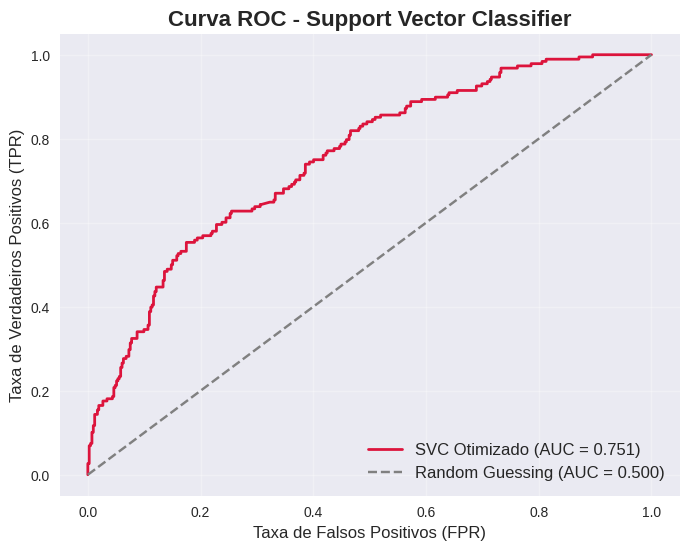

In [ ]:

# 1. Probabilidade de ser Inadimplente
prob_svc = modelo_svc_otimizado.predict_proba(X_test_RegLog_scaled)[:, 1]

# 2. Coordenadas e AUC
auc_svc = roc_auc_score(y_test, prob_svc)
fpr_svc, tpr_svc, _ = roc_curve(y_test, prob_svc)

# 3. Gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr_svc, tpr_svc, label=f'SVC Otimizado (AUC = {auc_svc:.3f})', linewidth=2, color='crimson')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - Support Vector Classifier', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Análise e comparação de resultados

Regressão

Calculando métricas comparativas

Comparação Modelos de Regressão:


,Modelo,R²,RMSE,MAE
0,XGBoost Regressor,0.199227,0.415079,0.349417
1,HistGradientBoosting,0.174801,0.421362,0.369162
2,KNN Regressor,0.114549,0.436474,0.362576


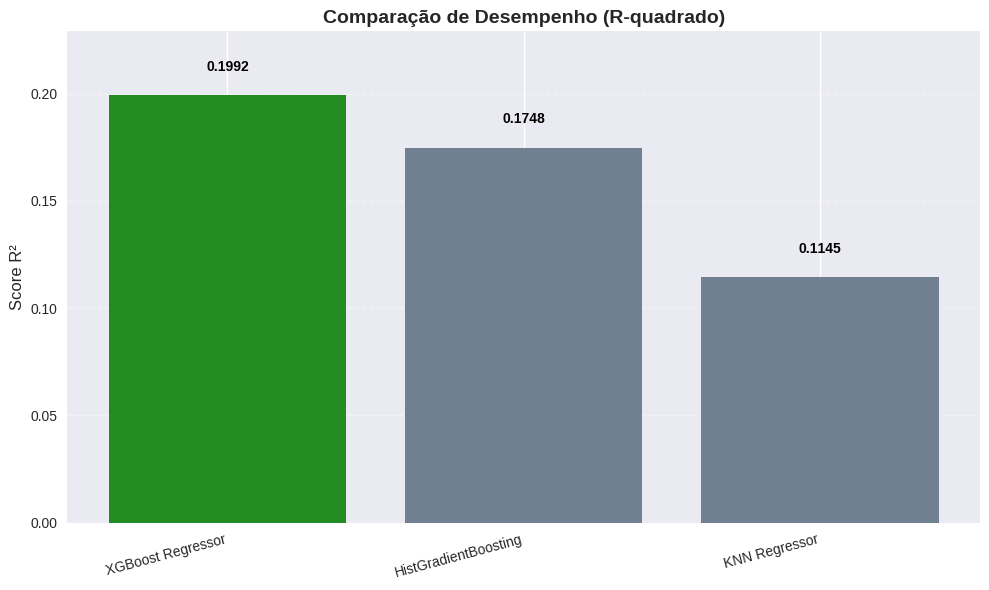

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


modelos_regressao = {
    'XGBoost Regressor': (modelo_xgb_reg_otimizado, X_test_RandForest),
    'HistGradientBoosting': (modelo_hgb_reg_otimizado, X_test_RandForest),
    'KNN Regressor': (modelo_knn_otimizado, X_test_Knn_scaled)

}

resultados_regressao = []

print("Calculando métricas comparativas\n")


for nome, (modelo, x_teste) in modelos_regressao.items():
    try:
        y_pred = modelo.predict(x_teste)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        resultados_regressao.append({
            'Modelo': nome,
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae
        })
    except NameError:
        print(f"Aviso: O modelo '{nome}' não foi encontrado na memória. Ele foi ignorado no gráfico.")
    except Exception as e:
         print(f"Erro ao avaliar '{nome}': {e}")

df_comparativo_reg = pd.DataFrame(resultados_regressao)

if not df_comparativo_reg.empty:
    df_comparativo_reg = df_comparativo_reg.sort_values(by='R²', ascending=False).reset_index(drop=True)

    print("Comparação Modelos de Regressão:")
    display(df_comparativo_reg)

    plt.figure(figsize=(10, 6))

    cores = ['forestgreen'] + ['slategray'] * (len(df_comparativo_reg) - 1)

    barras = plt.bar(df_comparativo_reg['Modelo'], df_comparativo_reg['R²'], color=cores)

    plt.title('Comparação de Desempenho (R-quadrado)', fontsize=14, fontweight='bold')
    plt.ylabel('Score R²', fontsize=12)
    plt.xticks(rotation=15, ha='right')

    plt.ylim(0, max(df_comparativo_reg['R²']) * 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    for barra in barras:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f'{altura:.4f}',
            ha='center',
            va='bottom',
            fontweight='bold',
            color='black'
        )

    plt.tight_layout()
    plt.show()
else:
    print("Nenhum modelo estava disponível na memória para gerar o comparativo.")

Classificação

A calcular métricas comparativas de classificação

Comparação modelos de classificação


,Modelo,AUC-ROC,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.785414,0.761667,0.714286,0.398936,0.511945
1,XGBoost Classifier,0.774311,0.760000,0.661765,0.478723,0.555556
2,Regressão Logística,0.765254,0.693333,0.507812,0.691489,0.585586
3,HistGradientBoosting,0.760309,0.676667,0.489583,0.750000,0.592437
4,SVC (Support Vector),0.751485,0.673333,0.484000,0.643617,0.552511
5,KNN Classifier,0.687455,0.645000,0.448980,0.585106,0.508083


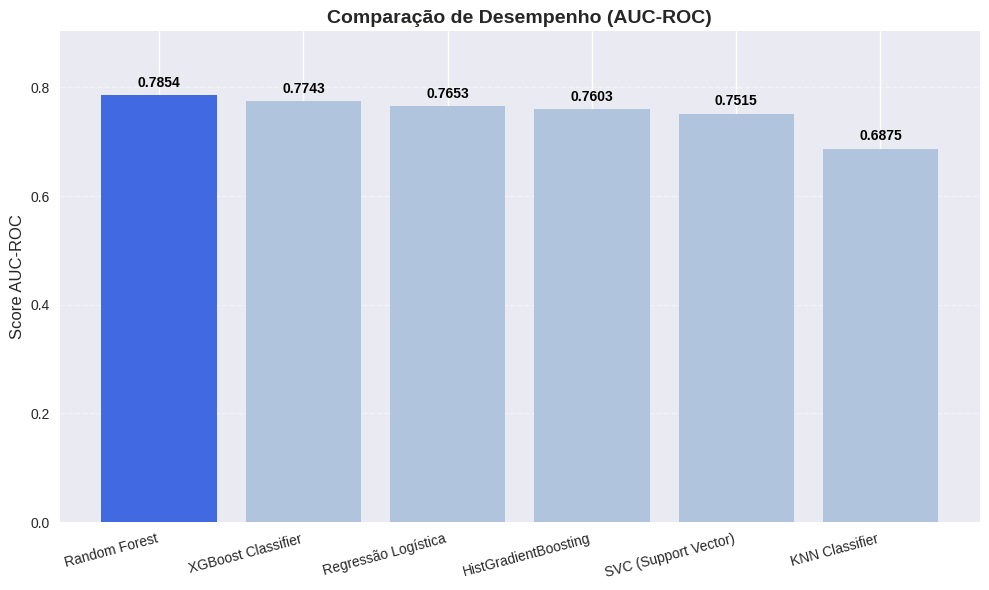

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

modelos_classificacao = {
    'XGBoost Classifier': (modelo_xgb_otimizado, X_test_RandForest),
    'HistGradientBoosting': (modelo_tree_avancado, X_test_RandForest),
    'Random Forest': (modelo_rf_otimizado, X_test_RandForest),
    'Regressão Logística': (modelo_lr_final, X_test_RegLog),
    'KNN Classifier': (modelo_knn_clf_otimizado, X_test_Knn_scaled),
    'SVC (Support Vector)': (modelo_svc_otimizado, X_test_RegLog_scaled)
}

resultados_classificacao = []

print("A calcular métricas comparativas de classificação\n")


for nome, (modelo, x_teste) in modelos_classificacao.items():
    try:
        y_pred = modelo.predict(x_teste)

        y_pred_prob = modelo.predict_proba(x_teste)[:, 1]

        auc = roc_auc_score(y_test, y_pred_prob)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        resultados_classificacao.append({
            'Modelo': nome,
            'AUC-ROC': auc,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })
    except NameError:
        print(f"Aviso: O modelo '{nome}' não foi encontrado na memória. Foi ignorado no gráfico.")
    except Exception as e:
         print(f"Erro ao avaliar '{nome}': {e}")

df_comparativo_clf = pd.DataFrame(resultados_classificacao)

if not df_comparativo_clf.empty:
    df_comparativo_clf = df_comparativo_clf.sort_values(by='AUC-ROC', ascending=False).reset_index(drop=True)

    print("Comparação modelos de classificação")
    display(df_comparativo_clf)

    plt.figure(figsize=(10, 6))

    cores = ['royalblue'] + ['lightsteelblue'] * (len(df_comparativo_clf) - 1)

    barras = plt.bar(df_comparativo_clf['Modelo'], df_comparativo_clf['AUC-ROC'], color=cores)

    plt.title('Comparação de Desempenho (AUC-ROC)', fontsize=14, fontweight='bold')
    plt.ylabel('Score AUC-ROC', fontsize=12)
    plt.xticks(rotation=15, ha='right')

    plt.ylim(0, max(df_comparativo_clf['AUC-ROC']) * 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    for barra in barras:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f'{altura:.4f}',
            ha='center',
            va='bottom',
            fontweight='bold',
            color='black'
        )

    plt.tight_layout()
    plt.show()
else:
    print("Nenhum modelo estava disponível na memória para gerar o comparativo.")